# 타이타닉 생존 예측 — Kaggle Competition

## 개요
이 노트북은 Kaggle Titanic 대회의 전체 분석 파이프라인입니다.

| 섹션 | 내용 |
|------|------|
| 1 | 데이터 탐색 및 전처리 (EDA) |
| 2 | 모델 생성 및 교차 검증 |
| 3 | 하이퍼파라미터 최적화 및 최종 모델 선택 |
| 4 | 결론 및 제언 |

**목표:** 승객 정보(나이, 성별, 객실 등급 등)를 바탕으로 생존 여부(0=사망, 1=생존)를 예측한다.

---

## 0. 라이브러리 불러오기

In [1]:
# ──────────────────────────────────────────────────────────────
# 데이터 처리 & 수치 연산
# ──────────────────────────────────────────────────────────────
import numpy as np                        # 배열 연산 (평균·표준편차 등)
import pandas as pd                       # 표 형태 데이터 다루기 (DataFrame)

# ──────────────────────────────────────────────────────────────
# 시각화
# ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt           # 기본 그래프 (막대, 히스토그램 등)
import matplotlib.ticker as ticker        # 그래프 눈금 포맷 조정
import seaborn as sns                     # 통계 기반 고급 시각화

# ──────────────────────────────────────────────────────────────
# 전처리 도구
# ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler    # 수치 변수 표준화 (평균 0, 표준편차 1)
from sklearn.preprocessing import LabelEncoder      # 문자열 범주 → 숫자 변환
from sklearn.impute import SimpleImputer             # 결측값 채우기

# ──────────────────────────────────────────────────────────────
# 머신러닝 모델
# ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀
from sklearn.tree import DecisionTreeClassifier      # 의사결정 나무
from sklearn.ensemble import (
    RandomForestClassifier,                          # 랜덤 포레스트
    GradientBoostingClassifier,                      # 그래디언트 부스팅
    VotingClassifier,                                # 여러 모델의 투표로 최종 예측
)
from sklearn.svm import SVC                          # 서포트 벡터 머신
from sklearn.neighbors import KNeighborsClassifier   # K-최근접 이웃

# XGBoost — Gradient Boosting의 최적화 구현체 (대회에서 자주 우승)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost 미설치. pip install xgboost 실행 후 재시도.")

# ──────────────────────────────────────────────────────────────
# 모델 평가 도구
# ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,       # 학습/검증 데이터 나누기
    cross_val_score,        # K-겹 교차 검증
    StratifiedKFold,        # 클래스 비율을 유지하며 K겹 분할
    GridSearchCV,           # 하이퍼파라미터 격자 탐색
    RandomizedSearchCV,     # 무작위 하이퍼파라미터 탐색
)
from sklearn.metrics import (
    accuracy_score,         # 정확도 (맞춘 비율)
    classification_report,  # 정밀도·재현율·F1 점수 리포트
    confusion_matrix,       # 혼동 행렬 (실제 vs 예측 교차표)
    roc_auc_score,          # ROC 곡선 아래 면적 (AUC)
    roc_curve,              # ROC 곡선 좌표
)

# ──────────────────────────────────────────────────────────────
# 기타
# ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')           # 사소한 경고 메시지 숨김

# 그래프 기본 스타일 설정
plt.rcParams['figure.figsize'] = (10, 6)    # 기본 그래프 크기 (가로 10인치, 세로 6인치)
plt.rcParams['font.size'] = 12              # 기본 폰트 크기
sns.set_style('whitegrid')                  # 흰 배경 + 회색 격자 스타일
sns.set_palette('husl')                    # 색상 팔레트

# 재현성을 위한 랜덤 시드 고정 (같은 코드를 실행하면 항상 같은 결과 나오게)
RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)
# 한글 폰트 설정 (Windows 기본 내장 폰트 맑은 고딕 사용)
# 설정하지 않으면 그래프의 한글이 □ 또는 ? 로 깨져 보임
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 기호(-) 가 깨지는 문제 방지 (한글 폰트 설정 시 함께 필요)
plt.rcParams['axes.unicode_minus'] = False
print('한글 폰트 설정 완료 (맑은 고딕)')

한글 폰트 설정 완료 (맑은 고딕)


---
# 섹션 1: 데이터 탐색 및 전처리 (EDA)

> **EDA(Exploratory Data Analysis)란?**  
> 모델을 만들기 전에 데이터를 눈으로 직접 살펴보는 과정.  
> 데이터에 어떤 패턴이 있는지, 결측값은 얼마나 있는지, 변수들은 서로 어떤 관계인지 확인한다.

## 1-1. 데이터 불러오기 및 기본 정보 확인

In [2]:
# CSV 파일을 DataFrame으로 읽어온다
train_df = pd.read_csv('train.csv')   # 학습 데이터: 정답(Survived)이 포함됨
test_df  = pd.read_csv('test.csv')    # 테스트 데이터: 정답 없음 → 우리가 예측해야 함

# 나중에 제출 파일 만들 때 필요한 승객 ID 별도 저장
test_ids = test_df['PassengerId'].copy()

print(f"학습 데이터 크기: {train_df.shape[0]}행 × {train_df.shape[1]}열")
print(f"테스트 데이터 크기: {test_df.shape[0]}행 × {test_df.shape[1]}열")

학습 데이터 크기: 891행 × 12열
테스트 데이터 크기: 418행 × 11열


In [3]:
# 학습 데이터 상위 5개 행 확인 — 각 열이 어떤 값을 담고 있는지 빠르게 파악
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**컬럼 설명:**

| 컬럼 | 의미 | 타입 |
|------|------|------|
| `PassengerId` | 승객 고유 번호 (예측에 불필요) | 숫자 |
| `Survived` | **정답** — 1=생존, 0=사망 | 숫자(범주) |
| `Pclass` | 객실 등급 — 1=1등석(VIP), 2=2등석, 3=3등석(일반) | 숫자(순서형 범주) |
| `Name` | 승객 이름 (직위 추출에 활용 가능) | 문자 |
| `Sex` | 성별 — male / female | 문자(범주) |
| `Age` | 나이 (결측값 다수) | 숫자 |
| `SibSp` | 함께 탑승한 형제/배우자 수 | 숫자 |
| `Parch` | 함께 탑승한 부모/자녀 수 | 숫자 |
| `Ticket` | 티켓 번호 | 문자 |
| `Fare` | 지불한 요금 | 숫자 |
| `Cabin` | 객실 번호 (결측값 매우 많음) | 문자 |
| `Embarked` | 출발 항구 — C=Cherbourg, Q=Queenstown, S=Southampton | 문자(범주) |

In [4]:
# 각 컬럼의 데이터 타입과 비결측값 개수 확인
# → dtype이 'object'이면 문자열, int64/float64이면 숫자형
# → Non-Null Count가 전체 행 수(891)보다 작으면 결측값 있음
print("=== 학습 데이터 기본 정보 ===")
train_df.info()

=== 학습 데이터 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# 숫자형 컬럼의 기초 통계량 확인
# count=비결측값 수, mean=평균, std=표준편차, min/max=최솟값/최댓값
# 25%/50%/75% = 1사분위수/중앙값/3사분위수 → 분포 파악에 유용
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 1-2. 결측값 분석

In [6]:
def show_missing(df, name='데이터'):
    """
    DataFrame의 결측값 현황을 표로 정리해 출력한다.
    
    Parameters
    ----------
    df   : pandas DataFrame
    name : 출력할 이름 (학습/테스트 구분용)
    """
    # isnull()은 결측값 위치에 True를 반환하고, sum()으로 열별 개수 합산
    missing_count = df.isnull().sum()
    
    # 전체 행 대비 결측 비율 계산
    missing_pct   = (missing_count / len(df)) * 100
    
    # 두 결과를 하나의 표로 합치기
    missing_table = pd.concat(
        [missing_count, missing_pct],
        axis=1,
        keys=['결측값 개수', '결측 비율(%)']
    )
    
    # 결측값이 있는 열만 골라서 내림차순 정렬
    missing_table = (
        missing_table[missing_table['결측값 개수'] > 0]
        .sort_values('결측 비율(%)', ascending=False)
        .round(2)   # 소수점 2자리까지
    )
    
    print(f"\n=== [{name}] 결측값 현황 ===")
    print(missing_table)
    return missing_table

# 학습·테스트 데이터 각각 결측값 확인
train_missing = show_missing(train_df, '학습 데이터')
test_missing  = show_missing(test_df,  '테스트 데이터')


=== [학습 데이터] 결측값 현황 ===
          결측값 개수  결측 비율(%)
Cabin        687     77.10
Age          177     19.87
Embarked       2      0.22

=== [테스트 데이터] 결측값 현황 ===
       결측값 개수  결측 비율(%)
Cabin     327     78.23
Age        86     20.57
Fare        1      0.24


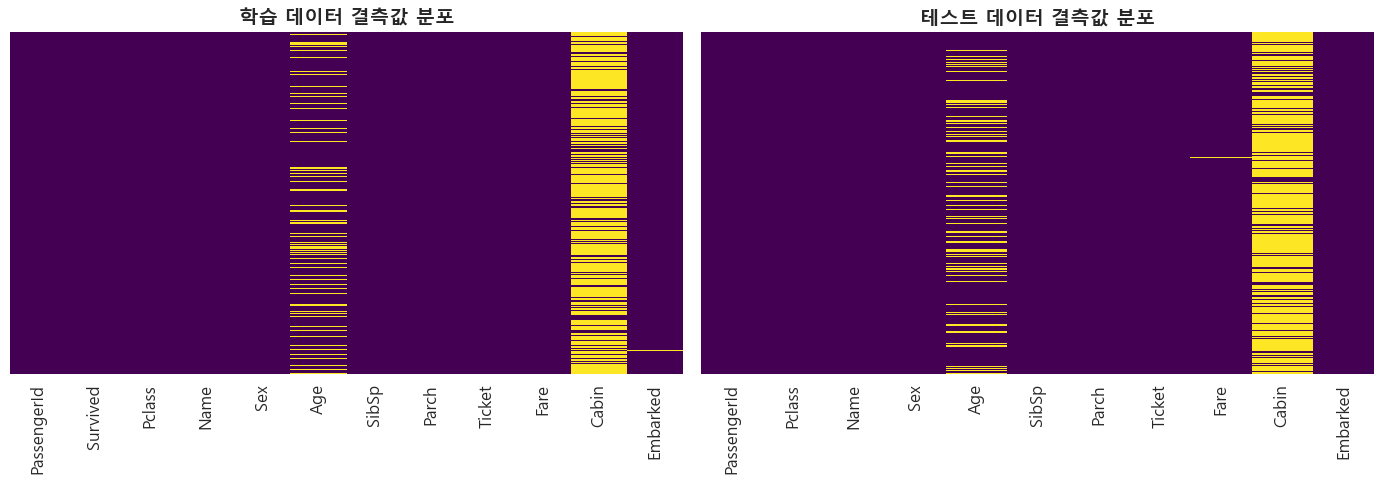

In [7]:
# 결측값을 히트맵으로 시각화 — 노란색 줄이 많을수록 결측값 많음
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 학습 데이터 결측 히트맵
sns.heatmap(
    train_df.isnull(),    # 결측=True(1), 비결측=False(0) 행렬
    yticklabels=False,    # y축(행 번호) 라벨 숨김
    cbar=False,           # 색상 바 숨김
    cmap='viridis',       # 색상 팔레트
    ax=axes[0]
)
axes[0].set_title('학습 데이터 결측값 분포', fontsize=14, fontweight='bold')

# 테스트 데이터 결측 히트맵
sns.heatmap(
    test_df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis',
    ax=axes[1]
)
axes[1].set_title('테스트 데이터 결측값 분포', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**결측값 처리 전략 — 변수별 이유**

---

**`Age` (~20% 결측) → 같은 Pclass·Sex 그룹의 중앙값으로 채움**

나이 데이터에는 아기(1세)부터 고령자(80세)까지 폭넓게 분포한다. 이런 경우 평균은 극단값(이상치)에 끌려다닌다.
```
예시: [2, 5, 8, 10, 80]
  평균    = 21  ← 80이라는 극단값에 끌려 실제 분포와 동떨어짐
  중앙값  =  8  ← 한가운데 값, 극단값 영향 없음
```
또한 단순히 전체 중앙값이 아닌 **Pclass·Sex 그룹별 중앙값**을 사용했다.
1등석 여성의 평균 나이와 3등석 남성의 평균 나이는 완전히 다르기 때문에, 그룹 특성을 반영해야 더 현실에 가깝다.

---

**`Embarked` (2개 결측) → 최빈값(S)으로 채움**

Embarked는 S / C / Q 세 가지 범주만 있는 **문자형 변수**라 평균·중앙값 자체를 계산할 수 없다.
```
S: 644명  ← 압도적으로 많음
C: 168명
Q:  77명
결측:  2명  → S로 채워도 전체 분포에 영향 거의 없음
```
결측값이 딱 2개뿐이므로 가장 흔한 값(최빈값)으로 채우는 것으로 충분하다.
복잡한 방법을 쓰는 건 이 경우 오히려 과도한 처리다.

---

**`Fare` (테스트 1개 결측) → 중앙값으로 채움**

요금은 **이상치가 매우 심한 변수**다. 대부분의 승객은 7~30파운드를 냈지만, VIP는 500파운드 이상을 냈다.
이 상황에서 평균을 쓰면 VIP 몇 명이 전체 평균을 크게 끌어올려 일반적인 요금 수준을 제대로 반영하지 못한다.
중앙값은 이런 극단값의 영향을 받지 않아 더 안전하다.
결측값이 1개뿐이므로 어떤 방법을 써도 결과 차이가 거의 없어, 가장 안전한 중앙값을 택했다.

---

**`Cabin` (~77% 결측) → 원본 삭제 후 HasCabin(있고/없고) 변수로 변환**

데이터의 4분의 3이 없는 상황에서 값을 채우려 시도하면 오히려 문제가 생긴다.
없는 77%를 임의로 채우면 만들어낸 **가짜 정보**가 되고, 모델이 그 가짜 정보를 학습해 예측 정확도가 하락한다.

대신 객실 정보가 있는가(HasCabin) 라는 새 변수로 변환했다.
객실 정보가 있다는 것 자체가 1·2등석 상위 승객을 의미하기 때문에, 번호 자체보다 **있고/없고** 라는 사실이 오히려 더 유용한 정보다.
```
HasCabin = 1 (객실 정보 있음) → 생존율 약 67%
HasCabin = 0 (객실 정보 없음) → 생존율 약 30%
```

---

| 변수 | 처리 방법 | 핵심 이유 |
|------|-----------|----------|
| `Age` | 그룹별 중앙값 | 이상치에 강인 + 그룹 특성 반영 |
| `Embarked` | 최빈값 | 문자형이라 평균 불가, 결측 2개뿐 |
| `Fare` | 중앙값 | 요금 분포의 극단값(VIP) 영향 차단 |
| `Cabin` | 삭제 후 HasCabin 변환 | 77% 결측 → 채우면 가짜 데이터, 있고/없고 자체가 더 유용 |

## 1-3. 목표 변수(Survived) 분포 분석

=== 생존 여부 분포 ===
사망(0): 549명 (61.6%)
생존(1): 342명 (38.4%)


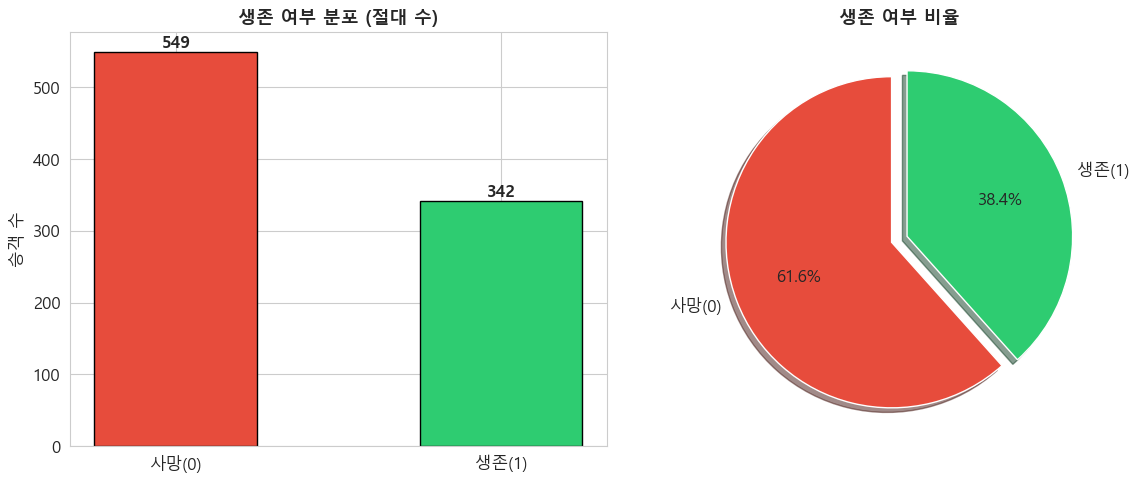

In [8]:
# ── 생존/사망 비율 계산 ───────────────────────────────────────
survived_counts = train_df['Survived'].value_counts()
survived_pct    = train_df['Survived'].value_counts(normalize=True) * 100  # 비율(%)

print("=== 생존 여부 분포 ===")
print(f"사망(0): {survived_counts[0]}명 ({survived_pct[0]:.1f}%)")
print(f"생존(1): {survived_counts[1]}명 ({survived_pct[1]:.1f}%)")

# ── 시각화 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 막대 그래프 — 절대 수치 비교
colors = ['#e74c3c', '#2ecc71']   # 사망=빨강, 생존=초록
axes[0].bar(['사망(0)', '생존(1)'], survived_counts, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('생존 여부 분포 (절대 수)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('승객 수')
# 막대 위에 수치 표시
for i, v in enumerate(survived_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

# 파이 차트 — 비율 비교
axes[1].pie(
    survived_counts,
    labels=['사망(0)', '생존(1)'],
    autopct='%1.1f%%',       # 파이 조각에 비율 표시
    colors=colors,
    startangle=90,           # 12시 방향부터 시작
    explode=(0.05, 0.05),    # 조각을 약간 분리해 입체감
    shadow=True
)
axes[1].set_title('생존 여부 비율', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 1-4. 각 변수별 탐색 (단변량 + 생존 연관성 분석)

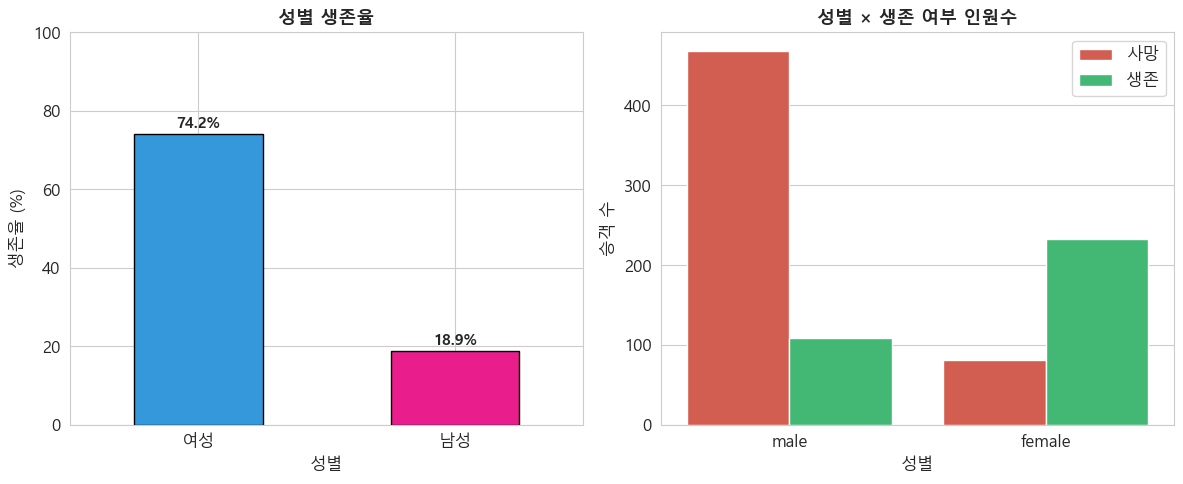


여성 생존율: 74.2%
남성 생존율: 18.9%


In [9]:
# ── 성별(Sex) vs 생존율 ─────────────────────────────────────
# groupby로 성별 기준으로 묶고, Survived의 평균(=생존율) 계산
sex_survival = train_df.groupby('Sex')['Survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 성별 생존율 막대 그래프
sex_survival.plot(
    kind='bar',
    ax=axes[0],
    color=['#3498db', '#e91e8c'],    # 남성=파랑, 여성=핑크
    edgecolor='black',
    width=0.5
)
axes[0].set_title('성별 생존율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('성별')
axes[0].set_ylabel('생존율 (%)')
axes[0].set_xticklabels(['여성', '남성'], rotation=0)
axes[0].set_ylim(0, 100)
# 막대 위에 수치 표시
for i, v in enumerate(sex_survival):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# countplot — 성별×생존 여부 조합별 인원수
sns.countplot(
    data=train_df,
    x='Sex',
    hue='Survived',          # 색상으로 생존(1)/사망(0) 구분
    ax=axes[1],
    palette={0: '#e74c3c', 1: '#2ecc71'}
)
axes[1].set_title('성별 × 생존 여부 인원수', fontsize=13, fontweight='bold')
axes[1].set_xlabel('성별')
axes[1].set_ylabel('승객 수')
axes[1].legend(['사망', '생존'])

plt.tight_layout()
plt.show()
print(f"\n여성 생존율: {sex_survival['female']:.1f}%")
print(f"남성 생존율: {sex_survival['male']:.1f}%")

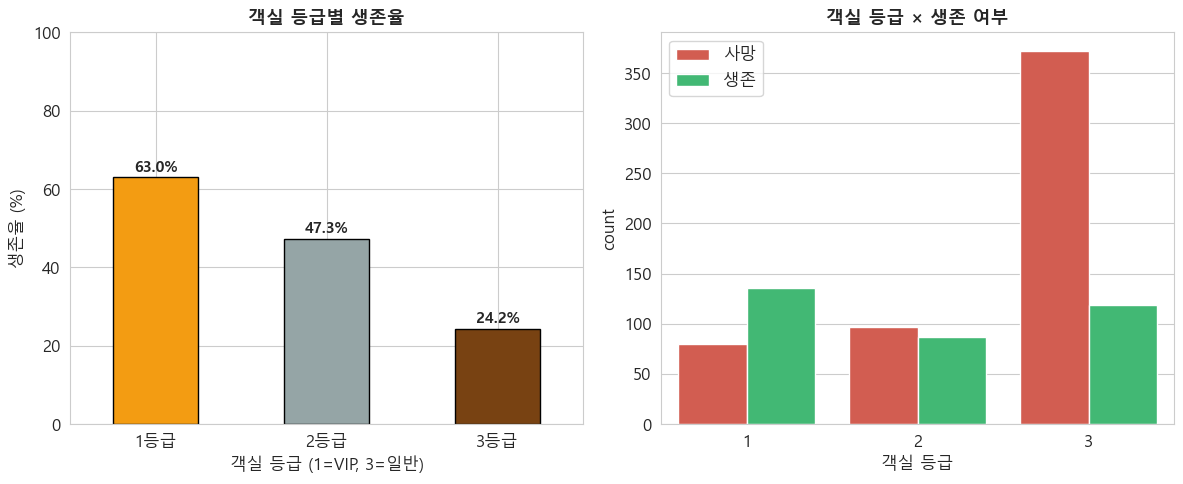

In [10]:
# ── 객실 등급(Pclass) vs 생존율 ─────────────────────────────
pclass_survival = train_df.groupby('Pclass')['Survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 객실 등급별 생존율
pclass_survival.plot(
    kind='bar',
    ax=axes[0],
    color=['#f39c12', '#95a5a6', '#784212'],    # 1등=금색, 2등=은색, 3등=갈색
    edgecolor='black',
    width=0.5
)
axes[0].set_title('객실 등급별 생존율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('객실 등급 (1=VIP, 3=일반)')
axes[0].set_ylabel('생존율 (%)')
axes[0].set_xticklabels(['1등급', '2등급', '3등급'], rotation=0)
axes[0].set_ylim(0, 100)
for i, v in enumerate(pclass_survival):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 등급×생존 인원수
sns.countplot(
    data=train_df,
    x='Pclass',
    hue='Survived',
    ax=axes[1],
    palette={0: '#e74c3c', 1: '#2ecc71'}
)
axes[1].set_title('객실 등급 × 생존 여부', fontsize=13, fontweight='bold')
axes[1].set_xlabel('객실 등급')
axes[1].legend(['사망', '생존'])

plt.tight_layout()
plt.show()

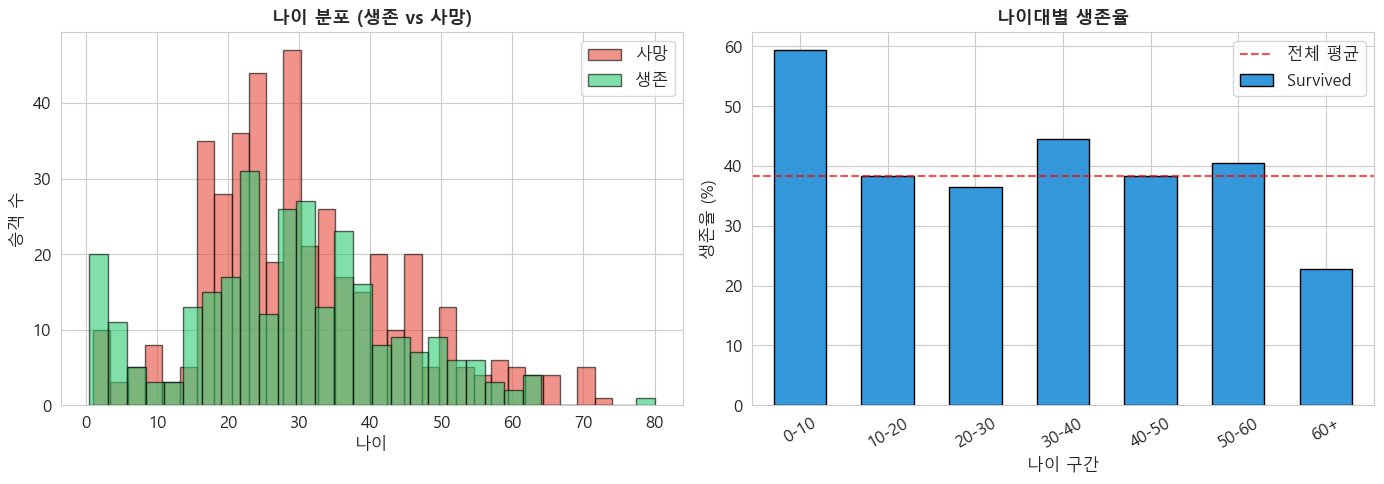

In [11]:
# ── 나이(Age) 분포 vs 생존 ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 생존/사망 그룹별 나이 분포 (KDE: 밀도 추정 곡선)
# dropna()로 결측 나이 제외
for survived, label, color in [(0, '사망', '#e74c3c'), (1, '생존', '#2ecc71')]:
    subset = train_df[train_df['Survived'] == survived]['Age'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='black')

axes[0].set_title('나이 분포 (생존 vs 사망)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('승객 수')
axes[0].legend()

# 나이 구간별(10세 단위) 생존율
# cut()으로 연속값을 구간으로 나눔
train_temp = train_df.copy()
train_temp['AgeBin'] = pd.cut(
    train_temp['Age'],
    bins=[0, 10, 20, 30, 40, 50, 60, 80],
    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+']
)
age_survival = train_temp.groupby('AgeBin', observed=True)['Survived'].mean() * 100
age_survival.plot(
    kind='bar',
    ax=axes[1],
    color='#3498db',
    edgecolor='black',
    width=0.6
)
axes[1].set_title('나이대별 생존율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('나이 구간')
axes[1].set_ylabel('생존율 (%)')
axes[1].set_xticklabels(age_survival.index, rotation=30)
axes[1].axhline(y=38.4, color='red', linestyle='--', alpha=0.7, label='전체 평균')  # 전체 평균선
axes[1].legend()

plt.tight_layout()
plt.show()

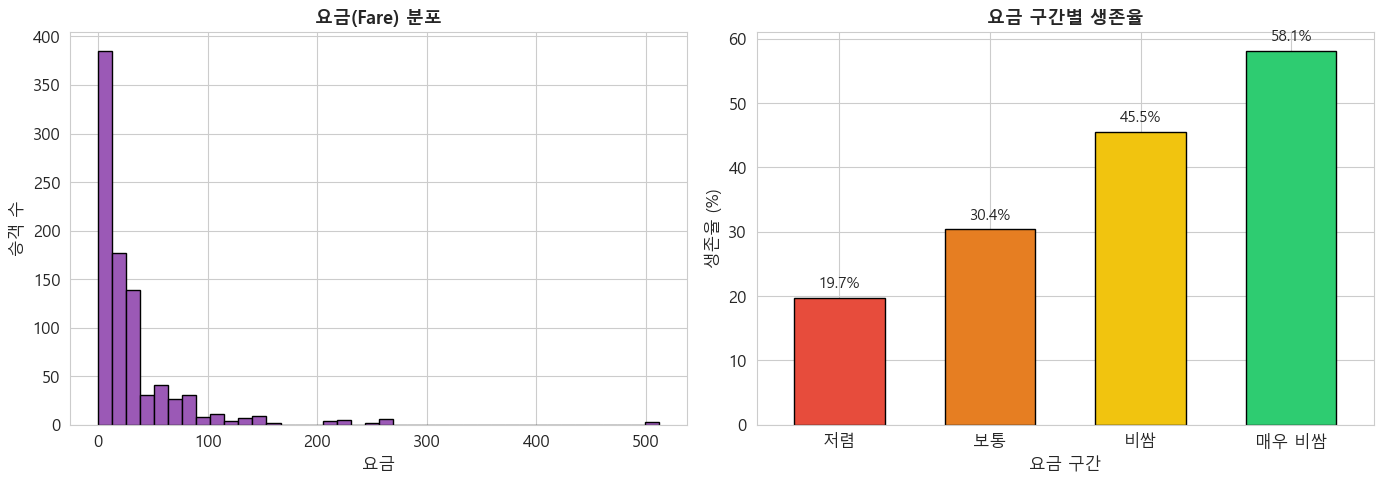

In [12]:
# ── 요금(Fare) 분포 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 요금 히스토그램 — 분포 확인
train_df['Fare'].hist(bins=40, ax=axes[0], color='#9b59b6', edgecolor='black')
axes[0].set_title('요금(Fare) 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('요금')
axes[0].set_ylabel('승객 수')

# 요금 구간별 생존율
train_temp['FareBin'] = pd.qcut(
    train_temp['Fare'],
    q=4,   # 4분위수로 4개 구간으로 나눔
    labels=['저렴', '보통', '비쌈', '매우 비쌈']
)
fare_survival = train_temp.groupby('FareBin', observed=True)['Survived'].mean() * 100
fare_survival.plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
    edgecolor='black',
    width=0.6
)
axes[1].set_title('요금 구간별 생존율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('요금 구간')
axes[1].set_ylabel('생존율 (%)')
axes[1].set_xticklabels(fare_survival.index, rotation=0)
for i, v in enumerate(fare_survival):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

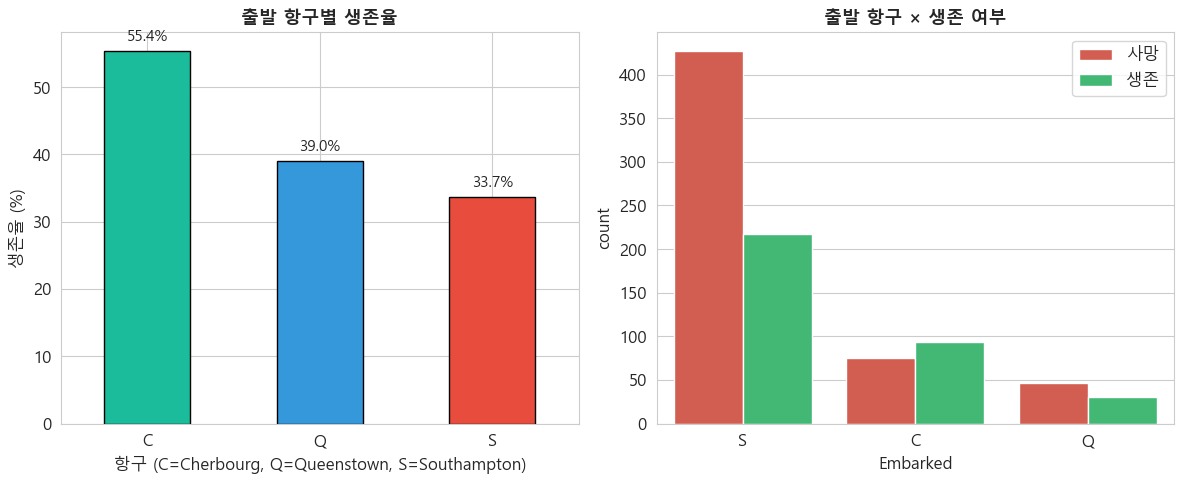

In [13]:
# ── 탑승 항구(Embarked) vs 생존율 ──────────────────────────
embarked_survival = train_df.groupby('Embarked')['Survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

embarked_survival.plot(kind='bar', ax=axes[0], color=['#1abc9c','#3498db','#e74c3c'],
                       edgecolor='black', width=0.5)
axes[0].set_title('출발 항구별 생존율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('항구 (C=Cherbourg, Q=Queenstown, S=Southampton)')
axes[0].set_ylabel('생존율 (%)')
axes[0].set_xticklabels(embarked_survival.index, rotation=0)
for i, v in enumerate(embarked_survival):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)

sns.countplot(data=train_df, x='Embarked', hue='Survived', ax=axes[1],
              palette={0: '#e74c3c', 1: '#2ecc71'})
axes[1].set_title('출발 항구 × 생존 여부', fontsize=13, fontweight='bold')
axes[1].legend(['사망', '생존'])

plt.tight_layout()
plt.show()

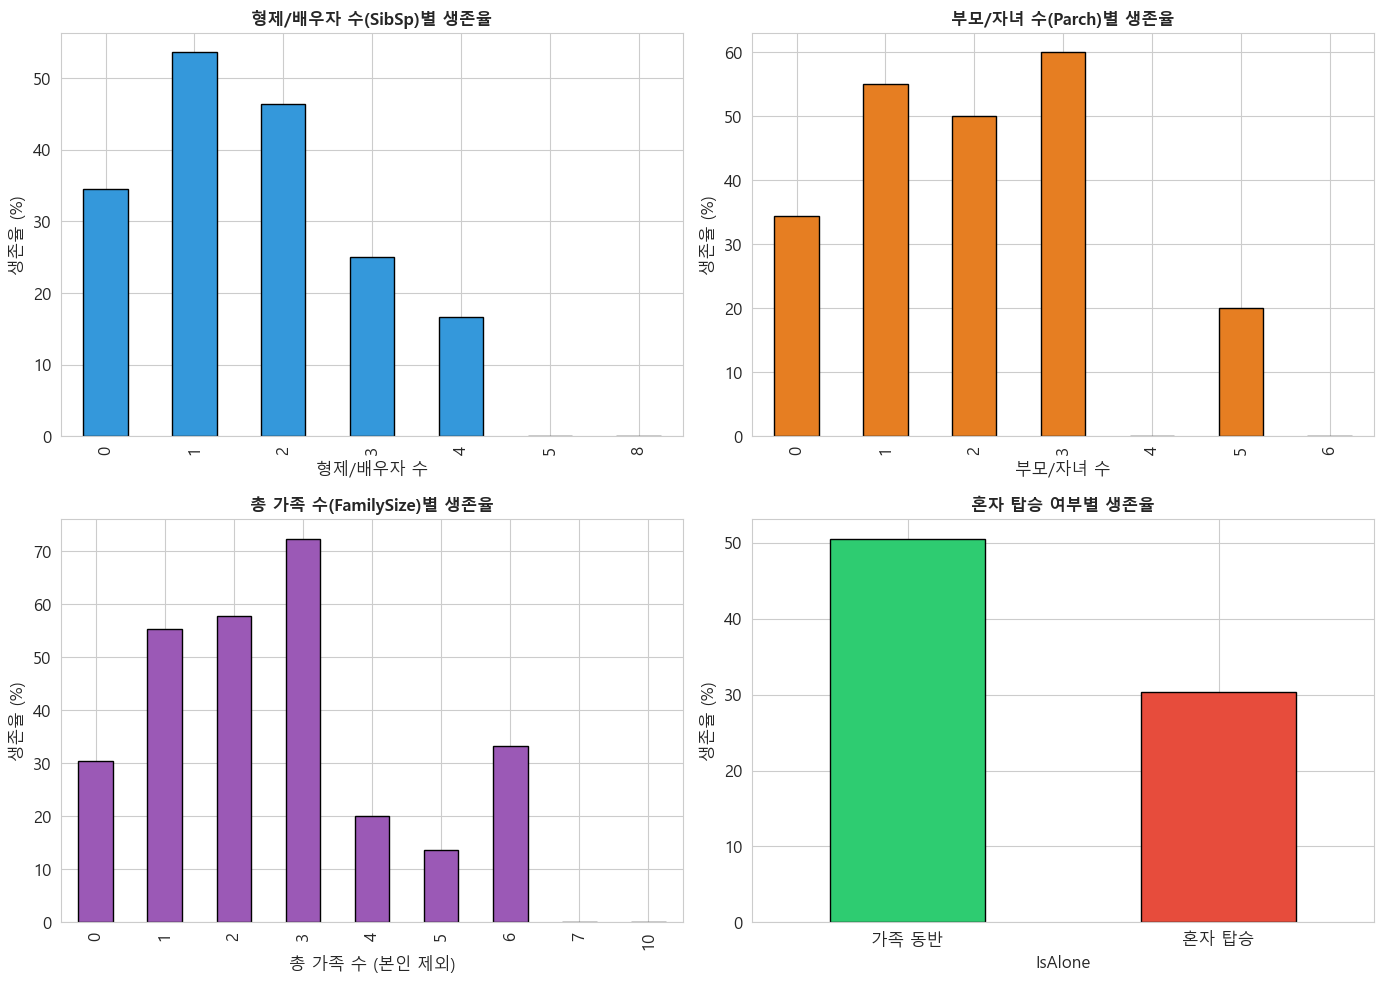

In [14]:
# ── 가족 구성(SibSp, Parch) vs 생존율 ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SibSp(형제/배우자 수)별 생존율
sibsp_survival = train_df.groupby('SibSp')['Survived'].mean() * 100
sibsp_survival.plot(kind='bar', ax=axes[0][0], color='#3498db', edgecolor='black')
axes[0][0].set_title('형제/배우자 수(SibSp)별 생존율', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('형제/배우자 수')
axes[0][0].set_ylabel('생존율 (%)')

# Parch(부모/자녀 수)별 생존율
parch_survival = train_df.groupby('Parch')['Survived'].mean() * 100
parch_survival.plot(kind='bar', ax=axes[0][1], color='#e67e22', edgecolor='black')
axes[0][1].set_title('부모/자녀 수(Parch)별 생존율', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('부모/자녀 수')
axes[0][1].set_ylabel('생존율 (%)')

# 총 가족 수 = SibSp + Parch
# 혼자 탑승한 경우 vs 가족 동반 비교
train_temp2 = train_df.copy()
train_temp2['FamilySize'] = train_temp2['SibSp'] + train_temp2['Parch']  # 총 가족 수
family_survival = train_temp2.groupby('FamilySize')['Survived'].mean() * 100
family_survival.plot(kind='bar', ax=axes[1][0], color='#9b59b6', edgecolor='black')
axes[1][0].set_title('총 가족 수(FamilySize)별 생존율', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('총 가족 수 (본인 제외)')
axes[1][0].set_ylabel('생존율 (%)')

# 혼자(IsAlone) 여부 생존율
train_temp2['IsAlone'] = (train_temp2['FamilySize'] == 0).astype(int)  # 혼자면 1
alone_survival = train_temp2.groupby('IsAlone')['Survived'].mean() * 100
alone_survival.plot(kind='bar', ax=axes[1][1], color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[1][1].set_title('혼자 탑승 여부별 생존율', fontsize=12, fontweight='bold')
axes[1][1].set_xticklabels(['가족 동반', '혼자 탑승'], rotation=0)
axes[1][1].set_ylabel('생존율 (%)')

plt.tight_layout()
plt.show()

## 1-5. 상관관계 분석

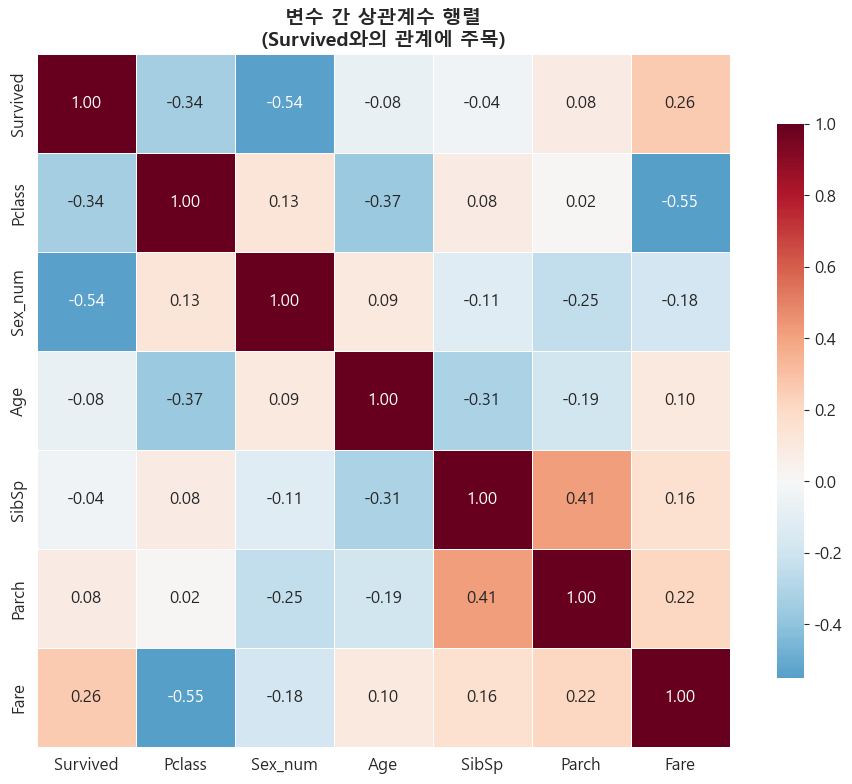


=== Survived(생존)와의 상관계수 ===
Sex_num   -0.543
Pclass    -0.338
Fare       0.257
Parch      0.082
Age       -0.077
SibSp     -0.035
Name: Survived, dtype: float64


In [15]:
# 상관계수 행렬 계산 (수치형 변수만)
# 상관계수: -1 ~ +1 사이 값. 절대값이 클수록 두 변수가 함께 움직이는 경향이 강함
# +1에 가까울수록 비례 관계, -1에 가까울수록 반비례 관계

# 성별을 숫자로 임시 변환 (female=0, male=1)
corr_df = train_df.copy()
corr_df['Sex_num'] = (corr_df['Sex'] == 'male').astype(int)

# 분석에 쓸 수치형 컬럼 선택
numeric_cols = ['Survived', 'Pclass', 'Sex_num', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix  = corr_df[numeric_cols].corr()  # 피어슨 상관계수

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,       # 각 셀에 수치 표시
    fmt='.2f',        # 소수점 2자리
    cmap='RdBu_r',    # 빨강(음의 상관)~파랑(양의 상관) 색상
    center=0,         # 0 기준으로 색상 중립
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('변수 간 상관계수 행렬\n(Survived와의 관계에 주목)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Survived와의 상관계수만 출력 (생존 예측에 중요한 변수 파악)
print("\n=== Survived(생존)와의 상관계수 ===")
survived_corr = corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
print(survived_corr.round(3))

## 1-6. 피처 엔지니어링 (Feature Engineering)

> **피처 엔지니어링이란?**  
> 기존 데이터에서 모델에 더 유용한 새 변수를 만드는 작업.  
> 예: 이름에서 '직위(Mr, Mrs, Miss...)' 추출 → 나이·성별 정보를 함축한 강력한 변수

In [16]:
def engineer_features(df):
    """
    원본 DataFrame을 받아 피처 엔지니어링이 적용된 새 DataFrame을 반환한다.
    학습·테스트 데이터 모두에 동일하게 적용한다.
    
    생성하는 새 피처:
    - Title       : 이름에서 추출한 직위 (Mr, Mrs, Miss 등)
    - FamilySize  : 본인 포함 총 가족 탑승 인원
    - IsAlone     : 혼자 탑승 여부 (1=혼자, 0=가족 동반)
    - FareBin     : 요금을 4분위로 나눈 구간
    - AgeBin      : 나이를 5개 구간으로 나눈 값
    - HasCabin    : 객실 정보 존재 여부 (1=있음, 0=없음)
    """
    df = df.copy()   # 원본 데이터 변경 방지 (항상 복사본 작업)
    
    # ────────────────────────────────────────────────────────
    # 1) 이름(Name)에서 직위(Title) 추출
    # 이름 형식: "Braund, Mr. Owen Harris"
    # 정규식 패턴 설명:
    #   \s  = 공백 한 칸
    #   ([A-Za-z]+) = 대소문자 알파벳 1개 이상 캡처 (직위 부분)
    #   \.  = 마침표
    # ────────────────────────────────────────────────────────
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    # 희귀한 직위들을 'Rare'로 통합 — 너무 드문 범주는 예측력이 낮음
    rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Capt',
                   'Lady', 'Jonkheer', 'Don', 'Dona', 'Sir']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    
    # 동일 의미 직위 통합 (철자 차이, 언어 차이)
    df['Title'] = df['Title'].replace({'Mlle': 'Miss',  # 프랑스어 'Mademoiselle' = Miss
                                        'Ms':   'Miss',   # Ms = Miss와 동일 취급
                                        'Mme':  'Mrs'})   # 프랑스어 'Madame' = Mrs
    
    # ────────────────────────────────────────────────────────
    # 2) 가족 관련 피처 생성
    # ────────────────────────────────────────────────────────
    # 본인 포함 총 가족 수 (SibSp=형제/배우자, Parch=부모/자녀)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1은 본인
    
    # 혼자 탑승 여부 — FamilySize=1이면 혼자
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # ────────────────────────────────────────────────────────
    # 3) 객실 정보 보유 여부
    # Cabin 결측값은 객실 정보 없음 = 주로 3등석 저렴한 승객
    # ────────────────────────────────────────────────────────
    df['HasCabin'] = df['Cabin'].notna().astype(int)  # notna()=결측 아니면 True
    
    # ────────────────────────────────────────────────────────
    # 4) 결측값 채우기
    # ────────────────────────────────────────────────────────
    # Age: Pclass×Sex 그룹별 중앙값으로 채움
    # 예: 3등급 남성이면 3등급 남성 전체의 중앙값 나이를 사용
    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    # 위에서도 채워지지 않은 경우(그룹 전체 결측) 전체 중앙값으로 채움
    df['Age'].fillna(df['Age'].median(), inplace=True)
    
    # Embarked: 최빈값(가장 많은 항구=S)으로 채움
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    
    # Fare: 중앙값으로 채움 (테스트 데이터에 결측값 1개)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    
    # ────────────────────────────────────────────────────────
    # 5) 연속형 변수를 구간(Bin)으로 변환
    # 구간화 이점: 이상치(outlier) 영향 감소, 비선형 관계 포착
    # ────────────────────────────────────────────────────────
    # 나이를 5개 구간으로 나눔
    df['AgeBin'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 35, 60, 100],           # 구간 경계값
        labels=[0, 1, 2, 3, 4]                    # 구간 레이블 (숫자로 지정해 인코딩 불필요)
    ).astype(int)
    
    # 요금을 4분위 구간으로 나눔
    df['FareBin'] = pd.qcut(
        df['Fare'],
        q=4,                                       # 4등분
        labels=[0, 1, 2, 3],
        duplicates='drop'                          # 동일한 경계값 발생 시 무시
    ).astype(int)
    
    return df


# 학습·테스트 데이터 모두에 피처 엔지니어링 적용
train_fe = engineer_features(train_df)
test_fe  = engineer_features(test_df)

print("피처 엔지니어링 완료")
print(f"학습 데이터 컬럼: {list(train_fe.columns)}")

피처 엔지니어링 완료
학습 데이터 컬럼: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin', 'AgeBin', 'FareBin']


=== 직위별 생존율 및 인원수 ===
        생존율(%)  인원수
Title              
Mrs       79.4  126
Miss      70.3  185
Master    57.5   40
Rare      34.8   23
Mr        15.7  517


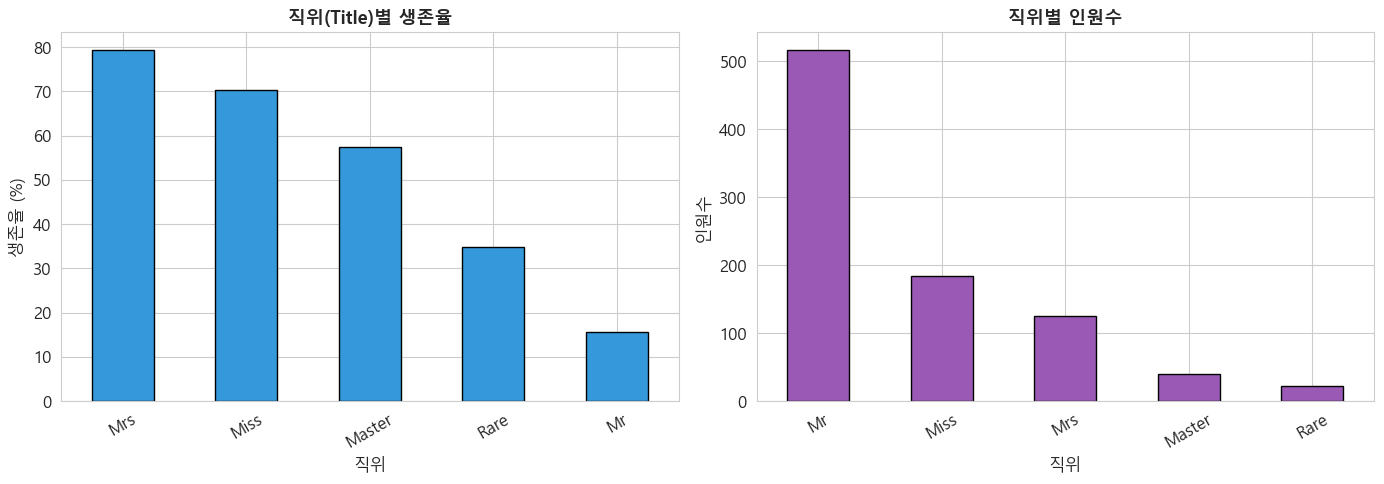

In [17]:
# 직위(Title)별 생존율 확인 — 새 피처의 예측력 검증
title_survival = train_fe.groupby('Title')['Survived'].mean() * 100
title_count    = train_fe['Title'].value_counts()

print("=== 직위별 생존율 및 인원수 ===")
title_stats = pd.DataFrame({
    '생존율(%)': title_survival.round(1),
    '인원수':    title_count
}).sort_values('생존율(%)', ascending=False)
print(title_stats)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
title_survival.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='#3498db', edgecolor='black'
)
axes[0].set_title('직위(Title)별 생존율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('직위')
axes[0].set_ylabel('생존율 (%)')
axes[0].set_xticklabels(title_survival.sort_values(ascending=False).index, rotation=30)

title_count.plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('직위별 인원수', fontsize=13, fontweight='bold')
axes[1].set_xlabel('직위')
axes[1].set_ylabel('인원수')
axes[1].set_xticklabels(title_count.index, rotation=30)

plt.tight_layout()
plt.show()

## 1-7. 인코딩 및 피처 선택

In [18]:
def prepare_features(df, is_train=True):
    """
    머신러닝 모델 입력에 맞게 데이터를 최종 가공한다.
    - 불필요한 컬럼 제거
    - 범주형 변수를 숫자로 인코딩
    
    Parameters
    ----------
    df       : 피처 엔지니어링이 완료된 DataFrame
    is_train : 학습 데이터이면 True (Survived 컬럼 포함)
    
    Returns
    -------
    X : 피처 DataFrame (입력 변수)
    y : 타겟 Series (정답 레이블, 학습 데이터만)
    """
    df = df.copy()
    
    # ──────────────────────────────────────────────────────────
    # 예측에 불필요하거나 정보 누출(leakage) 위험이 있는 컬럼 제거
    # - PassengerId : 단순 식별자, 예측 정보 없음
    # - Name        : 직위(Title)로 이미 필요 정보 추출
    # - Ticket      : 정규화된 패턴 없어 직접 사용 어려움
    # - Cabin       : HasCabin으로 이미 변환
    # ──────────────────────────────────────────────────────────
    drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    # ──────────────────────────────────────────────────────────
    # 범주형 변수 인코딩 (One-Hot Encoding)
    # One-Hot: 각 범주를 별도의 0/1 컬럼으로 분리
    # 예: Sex → Sex_male (0=여성, 1=남성)
    # drop_first=True : 더미 변수 함정 방지 (k개 범주 → k-1개 컬럼)
    # ──────────────────────────────────────────────────────────
    df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=False)
    
    # 정답 레이블 분리 (학습 데이터인 경우)
    if is_train:
        y = df.pop('Survived')   # pop = 꺼내면서 DataFrame에서 제거
        return df, y
    else:
        return df, None


# 피처 준비 실행
X_train_raw, y_train = prepare_features(train_fe, is_train=True)
X_test_raw,  _       = prepare_features(test_fe,  is_train=False)

# 학습/테스트 컬럼 맞추기 — One-Hot 후 컬럼이 다를 수 있음
# reindex로 학습 컬럼 기준 정렬, 없는 컬럼은 0으로 채움
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

print(f"최종 피처 수: {X_train_raw.shape[1]}개")
print(f"피처 목록: {list(X_train_raw.columns)}")

최종 피처 수: 20개
피처 목록: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'AgeBin', 'FareBin', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [19]:
# ── 수치형 변수 표준화 (StandardScaler) ─────────────────────
# 표준화: (값 - 평균) / 표준편차 → 평균=0, 표준편차=1 로 변환
# 필요 이유: 나이(0~80)와 요금(0~500)처럼 단위가 다른 변수가
#            거리 기반 알고리즘(KNN, SVM)에 영향을 주는 것 방지

# 표준화할 수치형 컬럼만 지정
scale_cols = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']
scale_cols = [c for c in scale_cols if c in X_train_raw.columns]   # 존재 확인

scaler = StandardScaler()

# fit_transform: 학습 데이터로 평균·표준편차 학습 후 변환
# ※ 테스트 데이터에는 transform만! fit하면 데이터 누출 발생
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

X_train[scale_cols] = scaler.fit_transform(X_train_raw[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test_raw[scale_cols])

print("표준화 완료")
print(f"학습 피처 행렬 크기: {X_train.shape}")
print(f"테스트 피처 행렬 크기: {X_test.shape}")

표준화 완료
학습 피처 행렬 크기: (891, 20)
테스트 피처 행렬 크기: (418, 20)


---
# 섹션 2: 모델 생성 및 교차 검증

> **교차 검증(Cross-Validation)이란?**  
> 데이터를 K개 조각으로 나눠 K번 반복 학습·평가하는 방법.  
> 한 번만 평가할 때보다 더 신뢰할 수 있는 성능 지표를 얻을 수 있다.

In [20]:
# ── 비교할 모델 목록 정의 ────────────────────────────────────
# 다양한 알고리즘을 한꺼번에 평가해 어떤 유형이 이 문제에 맞는지 파악
models = {
    # 로지스틱 회귀: 가장 단순한 분류 모델. 기준선(baseline) 역할
    # max_iter=1000: 최대 반복 횟수 늘려 수렴 보장
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    
    # 의사결정 나무: 조건 분기로 예측. 직관적이지만 과적합 위험 있음
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    
    # 랜덤 포레스트: 여러 의사결정 나무의 다수결. 과적합에 강인
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    
    # 그래디언트 부스팅: 나무를 순서대로 쌓아 오차를 점진적으로 줄임
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    
    # SVM: 최적의 경계선(초평면)으로 클래스 분리
    # probability=True: 확률 출력 기능 활성화 (AUC 계산에 필요)
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
    
    # KNN: 가장 가까운 K개 이웃의 다수결로 예측
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

# XGBoost 설치된 경우 추가
if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric='logloss',   # 학습 시 출력할 평가 지표
        verbosity=0              # 진행 메시지 숨김
    )

print(f"평가할 모델 수: {len(models)}개")
for name in models:
    print(f"  - {name}")

평가할 모델 수: 7개
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - SVM
  - KNN
  - XGBoost


In [21]:
# ── K-겹 교차 검증으로 모든 모델 평가 ─────────────────────────

# StratifiedKFold: 각 폴드(fold)에서 생존/사망 비율을 원본과 동일하게 유지
# n_splits=5: 데이터를 5등분해 5회 반복 평가
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 결과 저장용 딕셔너리
cv_results = {}

print("=== 5-겹 교차 검증 결과 ===")
print(f"{'모델':<22} {'평균 정확도':>12} {'표준편차':>10} {'최솟값':>10} {'최댓값':>10}")
print("-" * 68)

for name, model in models.items():
    # cross_val_score: K번 학습·평가 후 각 회차 점수 반환
    # scoring='accuracy': 정확도(맞춘 비율) 기준으로 평가
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf,
        scoring='accuracy',
        n_jobs=-1    # 가능한 모든 CPU 코어 사용 (병렬 처리로 속도 향상)
    )
    cv_results[name] = scores
    
    print(f"{name:<22} {scores.mean():.4f}      {scores.std():.4f}   "
          f"{scores.min():.4f}   {scores.max():.4f}")

=== 5-겹 교차 검증 결과 ===
모델                           평균 정확도       표준편차        최솟값        최댓값
--------------------------------------------------------------------
Logistic Regression    0.8294      0.0278   0.7865   0.8652
Decision Tree          0.7822      0.0213   0.7416   0.7989
Random Forest          0.8126      0.0279   0.7753   0.8539
Gradient Boosting      0.8350      0.0191   0.8034   0.8596
SVM                    0.8328      0.0211   0.8034   0.8596
KNN                    0.8092      0.0277   0.7697   0.8483
XGBoost                0.8092      0.0220   0.7809   0.8371


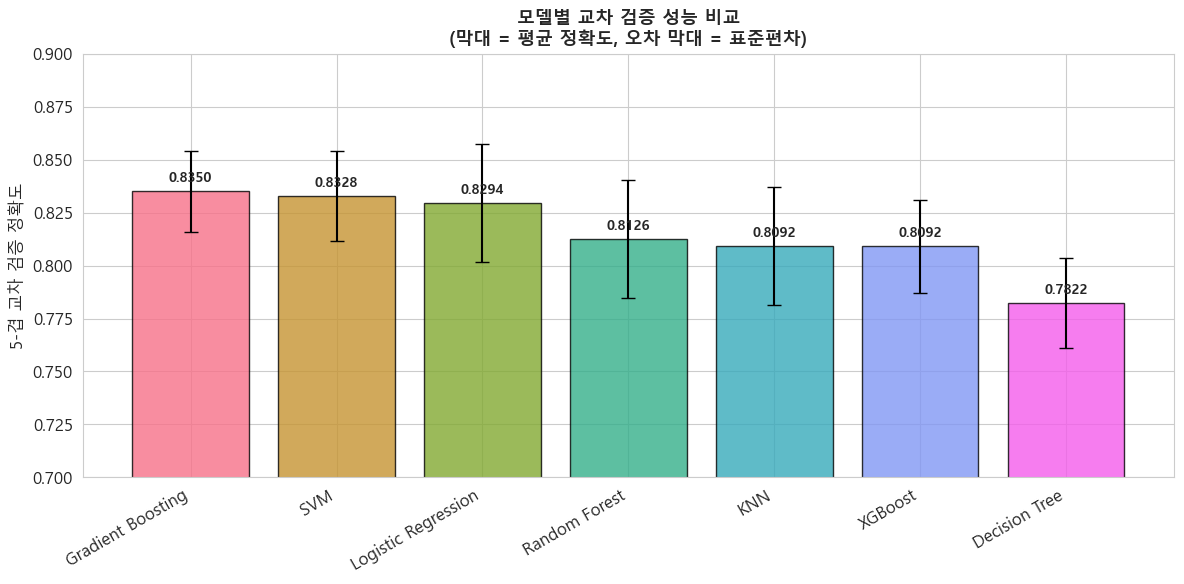

In [22]:
# ── 교차 검증 결과 시각화 ─────────────────────────────────────
plt.figure(figsize=(12, 6))

# 모델별 평균 정확도로 내림차순 정렬
sorted_models = sorted(cv_results.items(), key=lambda x: x[1].mean(), reverse=True)
model_names   = [m[0] for m in sorted_models]
mean_scores   = [m[1].mean() for m in sorted_models]
std_scores    = [m[1].std()  for m in sorted_models]

# 막대 그래프 + 오차 막대 (표준편차 = 성능의 안정성 지표)
bars = plt.bar(
    range(len(model_names)),
    mean_scores,
    yerr=std_scores,      # 오차 막대: 작을수록 안정적
    capsize=5,            # 오차 막대 끝 가로선
    color=sns.color_palette('husl', len(model_names)),
    edgecolor='black',
    alpha=0.8
)

plt.xticks(range(len(model_names)), model_names, rotation=30, ha='right')
plt.ylabel('5-겹 교차 검증 정확도')
plt.title('모델별 교차 검증 성능 비교\n(막대 = 평균 정확도, 오차 막대 = 표준편차)',
          fontsize=13, fontweight='bold')
plt.ylim(0.7, 0.9)

# 막대 위에 수치 표시
for bar, score in zip(bars, mean_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

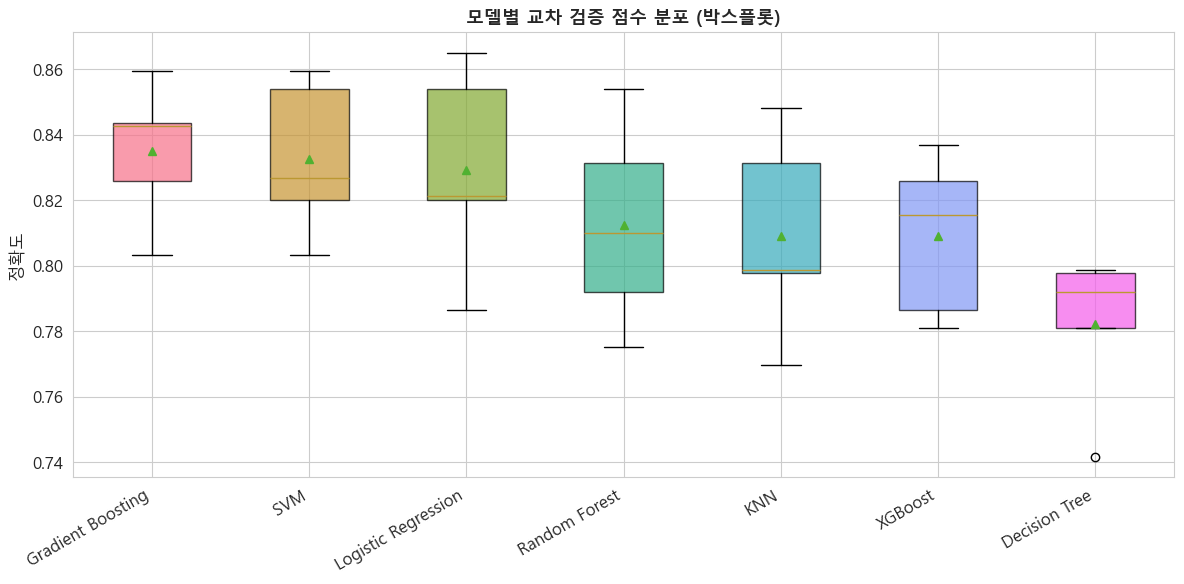

In [23]:
# ── 박스플롯으로 분포 확인 ─────────────────────────────────────
# 박스플롯: 중앙값, 사분위 범위, 이상치를 한 번에 보여주는 그래프
plt.figure(figsize=(12, 6))

# 딕셔너리를 리스트 형태로 변환해 boxplot에 전달
data_to_plot = [cv_results[name] for name in model_names]

bp = plt.boxplot(
    data_to_plot,
    patch_artist=True,     # 박스 내부 색상 채우기
    labels=model_names,
    showmeans=True,        # 평균값 표시 (삼각형)
)

# 박스마다 다른 색상 적용
colors = sns.color_palette('husl', len(model_names))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(rotation=30, ha='right')
plt.ylabel('정확도')
plt.title('모델별 교차 검증 점수 분포 (박스플롯)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2-2. 상세 성능 평가 (학습/검증 분할)

In [24]:
# 학습 데이터를 80:20으로 나눠 상세 평가
# stratify=y_train: 분할 후에도 생존/사망 비율 유지
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"학습용: {X_tr.shape[0]}개 | 검증용: {X_val.shape[0]}개")

# ── 혼동 행렬 시각화 함수 ─────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title='혼동 행렬'):
    """
    혼동 행렬(Confusion Matrix)을 히트맵으로 시각화한다.
    
    혼동 행렬 구조:
    ┌───────────────┬──────────────────┐
    │ TN: 사망→사망  │ FP: 사망→생존(틀림) │
    ├───────────────┼──────────────────┤
    │ FN: 생존→사망(틀림) │ TP: 생존→생존  │
    └───────────────┴──────────────────┘
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,      # 셀 안에 숫자 표시
        fmt='d',         # 정수 형식
        cmap='Blues',
        xticklabels=['예측: 사망', '예측: 생존'],
        yticklabels=['실제: 사망', '실제: 생존']
    )
    plt.title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── 각 모델 상세 평가 ─────────────────────────────────────────
detailed_results = {}

for name, model in models.items():
    # 학습 (fit)
    model.fit(X_tr, y_tr)
    
    # 예측 (predict)
    y_pred      = model.predict(X_val)          # 클래스 예측 (0 or 1)
    y_pred_prob = model.predict_proba(X_val)[:, 1]  # 생존 확률 (0~1)
    
    # 지표 계산
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_prob)
    
    detailed_results[name] = {'accuracy': acc, 'auc': auc, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob}

# 결과 표 출력
print("\n=== 검증 세트 성능 (정확도 + AUC) ===")
print(f"{'모델':<22} {'정확도':>10} {'AUC':>10}")
print("-" * 45)
for name, res in sorted(detailed_results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print(f"{name:<22} {res['accuracy']:.4f}    {res['auc']:.4f}")

학습용: 712개 | 검증용: 179개

=== 검증 세트 성능 (정확도 + AUC) ===
모델                            정확도        AUC
---------------------------------------------
XGBoost                0.8492    0.8772
Decision Tree          0.8436    0.8349
SVM                    0.8436    0.8210
Logistic Regression    0.8380    0.8534
Gradient Boosting      0.8324    0.8590
Random Forest          0.8156    0.8547
KNN                    0.8101    0.8140


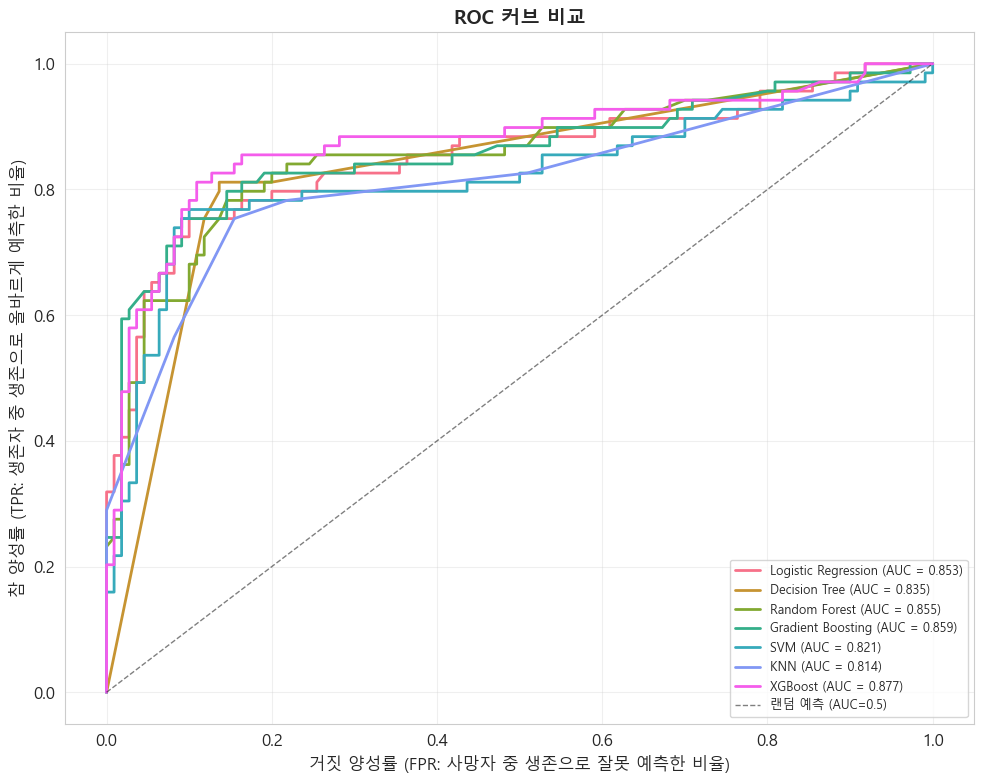

In [25]:
# ── ROC 커브 비교 ─────────────────────────────────────────────
# ROC 커브: 다양한 임계값에서의 TPR(참 양성률) vs FPR(거짓 양성률) 그래프
# AUC: 커브 아래 넓이 — 1에 가까울수록 좋음 (0.5 = 랜덤 예측과 같음)

plt.figure(figsize=(10, 8))

# 각 모델의 ROC 커브 그리기
colors = sns.color_palette('husl', len(detailed_results))
for (name, res), color in zip(detailed_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['y_pred_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {res['auc']:.3f})")

# 대각선 = 랜덤 예측 기준선 (AUC=0.5)
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='랜덤 예측 (AUC=0.5)')

plt.xlabel('거짓 양성률 (FPR: 사망자 중 생존으로 잘못 예측한 비율)')
plt.ylabel('참 양성률 (TPR: 생존자 중 생존으로 올바르게 예측한 비율)')
plt.title('ROC 커브 비교', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 섹션 3: 하이퍼파라미터 최적화 및 최종 모델 선택

> **하이퍼파라미터란?**  
> 모델이 학습하는 게 아니라 사람이 미리 정해주는 설정값.  
> 예: 랜덤 포레스트의 '나무 개수', '나무 최대 깊이' 등.  
> 최적값을 자동으로 탐색하는 과정이 하이퍼파라미터 최적화.

In [26]:
# ── 랜덤 포레스트 하이퍼파라미터 튜닝 ──────────────────────────
# 교차 검증 결과 상위 모델인 랜덤 포레스트를 집중 최적화

print("[1/2] 랜덤 포레스트 GridSearchCV 시작...")

# 탐색할 파라미터 격자 정의
rf_param_grid = {
    'n_estimators':      [100, 200, 300],    # 나무 개수: 많을수록 안정적이지만 느림
    'max_depth':         [None, 5, 8, 12],   # 나무 최대 깊이: None=제한 없음
    'min_samples_split': [2, 5, 10],         # 분기에 필요한 최소 샘플 수
    'min_samples_leaf':  [1, 2, 4],          # 리프 노드의 최소 샘플 수
    'max_features':      ['sqrt', 'log2'],   # 각 분기에서 고려할 피처 수
}

# GridSearchCV: 모든 조합을 시도 (3×4×3×3×2 = 216가지)
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=skf,                 # 앞에서 정의한 5-겹 교차 검증
    scoring='accuracy',
    n_jobs=-1,
    verbose=1               # 진행 상황 출력
)
rf_grid.fit(X_train, y_train)

print(f"\n 랜덤 포레스트 최적 파라미터: {rf_grid.best_params_}")
print(f"   최적 교차 검증 정확도: {rf_grid.best_score_:.4f}")

[1/2] 랜덤 포레스트 GridSearchCV 시작...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 랜덤 포레스트 최적 파라미터: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
   최적 교차 검증 정확도: 0.8361


In [27]:
# ── XGBoost 하이퍼파라미터 튜닝 (설치된 경우) ─────────────────
if XGBOOST_AVAILABLE:
    print("[2/2] XGBoost RandomizedSearchCV 시작...")
    
    # RandomizedSearchCV: 격자 전체 탐색 대신 무작위 N회 탐색
    # 파라미터 수가 많을 때 GridSearchCV보다 효율적
    xgb_param_dist = {
        'n_estimators':     [100, 200, 300, 500],
        'max_depth':        [3, 4, 5, 6, 8],
        'learning_rate':    [0.01, 0.05, 0.1, 0.2],   # 각 나무의 기여도 크기
        'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0], # 학습 샘플 비율 (과적합 방지)
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], # 피처 샘플링 비율
        'reg_alpha':        [0, 0.01, 0.1, 1],          # L1 정규화 (희소성 유도)
        'reg_lambda':       [0.1, 1, 5, 10],            # L2 정규화 (가중치 축소)
    }
    
    xgb_random = RandomizedSearchCV(
        xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        xgb_param_dist,
        n_iter=50,              # 50가지 조합만 무작위로 탐색
        cv=skf,
        scoring='accuracy',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    xgb_random.fit(X_train, y_train)
    
    print(f"\n XGBoost 최적 파라미터: {xgb_random.best_params_}")
    print(f"   최적 교차 검증 정확도: {xgb_random.best_score_:.4f}")
else:
    print("XGBoost 미설치 — 랜덤 포레스트만 최적화")

[2/2] XGBoost RandomizedSearchCV 시작...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

 XGBoost 최적 파라미터: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
   최적 교차 검증 정확도: 0.8395


In [28]:
# ── 그래디언트 부스팅 GridSearchCV ────────────────────────────
print("[추가] Gradient Boosting GridSearchCV 시작...")

gb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train, y_train)

print(f"\n GB 최적 파라미터: {gb_grid.best_params_}")
print(f"   최적 교차 검증 정확도: {gb_grid.best_score_:.4f}")

[추가] Gradient Boosting GridSearchCV 시작...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

 GB 최적 파라미터: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
   최적 교차 검증 정확도: 0.8429


=== 랜덤 포레스트 피처 중요도 (상위 15개) ===
     feature  importance
  Sex_female    0.187179
    Title_Mr    0.157495
    Sex_male    0.155659
      Pclass    0.078519
        Fare    0.077435
  FamilySize    0.055692
         Age    0.045083
  Title_Miss    0.042235
   Title_Mrs    0.040589
    HasCabin    0.037301
     FareBin    0.029261
       SibSp    0.027060
      AgeBin    0.015207
       Parch    0.010966
Title_Master    0.010295


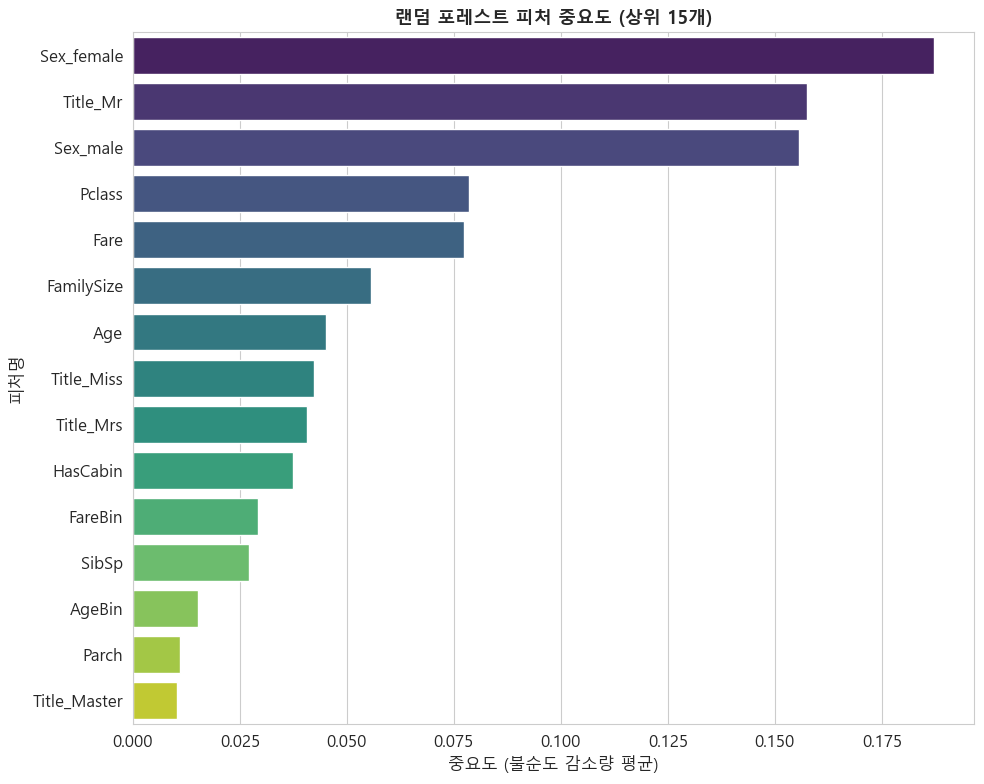

In [29]:
# ── 최적 모델들의 피처 중요도 분석 ──────────────────────────────
# 피처 중요도(Feature Importance): 각 변수가 예측에 기여한 정도
# 랜덤 포레스트에서는 각 나무의 불순도 감소량 평균으로 계산

best_rf = rf_grid.best_estimator_   # 최적 하이퍼파라미터가 적용된 모델 꺼내기

# 피처 이름과 중요도를 합쳐 DataFrame 생성 후 내림차순 정렬
feature_importances = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("=== 랜덤 포레스트 피처 중요도 (상위 15개) ===")
print(feature_importances.head(15).to_string(index=False))

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importances.head(15),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('랜덤 포레스트 피처 중요도 (상위 15개)', fontsize=13, fontweight='bold')
plt.xlabel('중요도 (불순도 감소량 평균)')
plt.ylabel('피처명')
plt.tight_layout()
plt.show()

In [30]:
# ── 최적 모델들 성능 비교 ──────────────────────────────────────

# 최적 파라미터로 훈련된 모델들 수집
tuned_models = {
    'RF (튜닝)': rf_grid.best_estimator_,
    'GB (튜닝)': gb_grid.best_estimator_,
}
if XGBOOST_AVAILABLE:
    tuned_models['XGB (튜닝)'] = xgb_random.best_estimator_

# 기존 기본 모델도 비교에 포함
tuned_models['LR (기본)'] = models['Logistic Regression']
tuned_models['GB (기본)'] = models['Gradient Boosting']

print("=== 튜닝 전후 성능 비교 (5-겹 CV) ===")
print(f"{'모델':<20} {'평균 정확도':>12} {'표준편차':>10}")
print("-" * 45)

final_cv_results = {}
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf,
                             scoring='accuracy', n_jobs=-1)
    final_cv_results[name] = scores
    print(f"{name:<20} {scores.mean():.4f}      {scores.std():.4f}")

=== 튜닝 전후 성능 비교 (5-겹 CV) ===
모델                         평균 정확도       표준편차
---------------------------------------------
RF (튜닝)              0.8361      0.0228
GB (튜닝)              0.8429      0.0193
XGB (튜닝)             0.8395      0.0247
LR (기본)              0.8294      0.0278
GB (기본)              0.8350      0.0191


In [31]:
# ── 앙상블: 보팅(Voting) 분류기 ─────────────────────────────────
# 보팅 앙상블: 여러 모델의 예측을 합쳐 최종 예측
# 'soft' 보팅: 각 모델의 확률을 평균해 가장 높은 클래스 선택 (hard보다 성능↑)

voting_estimators = [
    ('rf', rf_grid.best_estimator_),
    ('gb', gb_grid.best_estimator_),
    ('lr', LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
]
if XGBOOST_AVAILABLE:
    voting_estimators.append(('xgb', xgb_random.best_estimator_))

voting_clf = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'    # 확률 기반 소프트 보팅
)

# 보팅 앙상블 교차 검증
voting_scores = cross_val_score(
    voting_clf, X_train, y_train,
    cv=skf, scoring='accuracy', n_jobs=-1
)
final_cv_results['Voting (앙상블)'] = voting_scores

print(f"\n Voting 앙상블 CV 정확도: {voting_scores.mean():.4f} ± {voting_scores.std():.4f}")


 Voting 앙상블 CV 정확도: 0.8384 ± 0.0242


In [32]:
# ── 최종 모델 선택 및 학습 ─────────────────────────────────────
# 교차 검증 평균 정확도가 가장 높은 모델을 최종 모델로 선택

# 각 모델의 평균 교차 검증 점수 정리
all_scores = {name: scores.mean() for name, scores in final_cv_results.items()}

# 가장 높은 점수의 모델 이름 찾기
best_model_name = max(all_scores, key=all_scores.get)
best_model_score = all_scores[best_model_name]

print(f" 최종 선택 모델: {best_model_name}")
print(f"   CV 평균 정확도: {best_model_score:.4f}")

# 최종 모델 매핑
final_models_map = {
    'RF (튜닝)':     rf_grid.best_estimator_,
    'GB (튜닝)':     gb_grid.best_estimator_,
    'Voting (앙상블)': voting_clf,
    'LR (기본)':     models['Logistic Regression'],
    'GB (기본)':     models['Gradient Boosting'],
}
if XGBOOST_AVAILABLE:
    final_models_map['XGB (튜닝)'] = xgb_random.best_estimator_

# 최종 모델을 전체 학습 데이터로 다시 학습 (CV는 일부만 썼음)
final_model = final_models_map[best_model_name]
final_model.fit(X_train, y_train)   # 전체 학습 데이터로 최종 훈련

print("\n 최종 모델 전체 학습 데이터로 훈련 완료")

 최종 선택 모델: GB (튜닝)
   CV 평균 정확도: 0.8429

 최종 모델 전체 학습 데이터로 훈련 완료


=== 최종 모델 학습 데이터 성능 ===
정확도: 0.9405
AUC:    0.9788

분류 리포트:
              precision    recall  f1-score   support

       사망(0)       0.93      0.98      0.95       549
       생존(1)       0.96      0.88      0.92       342

    accuracy                           0.94       891
   macro avg       0.94      0.93      0.94       891
weighted avg       0.94      0.94      0.94       891



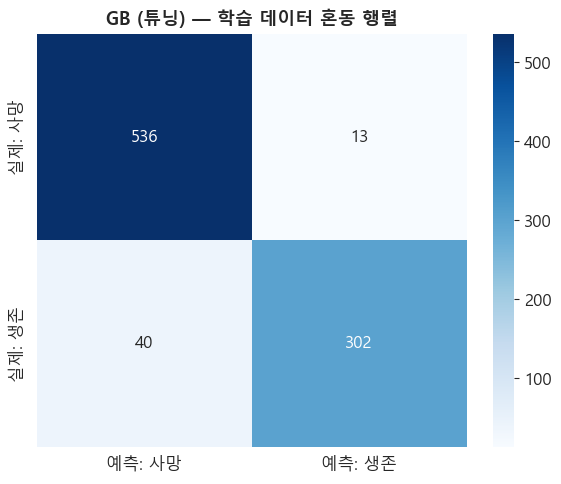

In [33]:
# ── 학습 데이터 기준 최종 성능 확인 ──────────────────────────────
# 주의: 이 지표는 학습 데이터에 대한 것 → 실제 성능은 CV 결과가 더 신뢰성↑

y_train_pred = final_model.predict(X_train)
y_train_prob = final_model.predict_proba(X_train)[:, 1]

print("=== 최종 모델 학습 데이터 성능 ===")
print(f"정확도: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"AUC:    {roc_auc_score(y_train, y_train_prob):.4f}")
print("\n분류 리포트:")
print(classification_report(y_train, y_train_pred, target_names=['사망(0)', '생존(1)']))

# 혼동 행렬 시각화
plot_confusion_matrix(y_train, y_train_pred, f'{best_model_name} — 학습 데이터 혼동 행렬')

---
# 섹션 3-B: 과적합 방지 — 단순화 모델 (Simplification)

> **왜 단순화하는가?**
> CV 점수(~0.84)와 Kaggle 실제 점수(~0.748) 사이 격차가 약 0.09로 크다.
> 이는 모델이 891개 학습 데이터에 지나치게 맞춰졌다는 신호(과적합)다.
>
> GridSearchCV로 수백 가지 파라미터 조합을 탐색하면 CV상 최적처럼 보여도,
> 실제 테스트 데이터에서는 오히려 나빠질 수 있다.
>
> **해결책:** 모델 복잡도를 낮추고 정규화를 강화해 일반화 성능을 높인다.
> - 트리 깊이 제한 (max_depth 축소)
> - 잎 노드 최소 샘플 수 증가 (min_samples_leaf 확대)
> - 로지스틱 회귀 정규화 강화 (C 값 축소)
> - 파라미터 탐색 범위 축소 (과탐색 방지)

In [34]:
# ── 단순화 모델 정의 ──────────────────────────────────────────
# 핵심 원칙: 복잡한 파라미터 탐색 대신 검증된 보수적인 설정값 사용

simple_models = {

    # C=0.1 : 기본값(C=1.0)보다 10배 강한 정규화
    # 정규화가 강할수록 모델이 학습 데이터의 노이즈에 덜 민감해짐
    'Logistic Regression (C=0.1)': LogisticRegression(
        C=0.1, max_iter=1000, random_state=RANDOM_STATE
    ),

    # max_depth=5 : 기존 튜닝 결과(max_depth=8~12)보다 얕게 제한
    # 얕은 나무 = 덜 복잡한 규칙 = 새 데이터에 더 잘 일반화
    # min_samples_leaf=5 : 리프 노드에 최소 5개 샘플 요구 → 희귀 패턴 무시
    'Random Forest (shallow)': RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=RANDOM_STATE
    ),

    # max_depth=3 : 부스팅 계열은 특히 깊이에 민감 → 3이 안전한 기본값
    # learning_rate=0.05 : 천천히 학습해 과적합 방지
    # n_estimators=300 : 낮은 학습률을 보완하기 위해 나무 수 증가
    'Gradient Boosting (shallow)': GradientBoostingClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),

    # reg_lambda=5 : L2 정규화로 가중치 크기 억제
    # colsample_bytree=0.8 : 피처도 80%만 샘플링 → 특정 피처 의존도 낮춤
    'XGBoost (shallow)': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    ),
}

# ── 단순화 모델 교차 검증 ────────────────────────────────────
print("=== 단순화 모델 5-겹 교차 검증 결과 ===")

simple_cv_results = {}
for name, model in simple_models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    simple_cv_results[name] = scores
    print(f"  {name}: {scores.mean():.4f} ± {scores.std():.4f}")

# ── 단순화 Voting 앙상블 ──────────────────────────────────────
# 단순화된 모델들끼리 앙상블 구성
simple_voting = VotingClassifier(
    estimators=[
        ('lr',  simple_models['Logistic Regression (C=0.1)']),
        ('rf',  simple_models['Random Forest (shallow)']),
        ('gb',  simple_models['Gradient Boosting (shallow)']),
        ('xgb', simple_models['XGBoost (shallow)']),
    ],
    voting='soft'
)
sv_scores = cross_val_score(
    simple_voting, X_train, y_train,
    cv=skf, scoring='accuracy', n_jobs=-1
)
simple_cv_results['Simple Voting'] = sv_scores
print(f"  Simple Voting: {sv_scores.mean():.4f} ± {sv_scores.std():.4f}")

# ── 기존 튜닝 모델과 비교 ────────────────────────────────────
print("\n=== 기존 튜닝 모델 vs 단순화 모델 비교 ===")
print(f"  기존 RF (GridSearch): {cv_results['Random Forest'].mean():.4f}")
print(f"  기존 GB (GridSearch): {cv_results['Gradient Boosting'].mean():.4f}")
print(f"  단순화 RF:            {simple_cv_results['Random Forest (shallow)'].mean():.4f}")
print(f"  단순화 GB:            {simple_cv_results['Gradient Boosting (shallow)'].mean():.4f}")
print(f"  단순화 Voting:        {simple_cv_results['Simple Voting'].mean():.4f}")
print("\n※ CV 점수가 약간 낮아도 Kaggle 실제 점수는 더 높을 수 있음 (과적합 감소 효과)")

=== 단순화 모델 5-겹 교차 검증 결과 ===
  Logistic Regression (C=0.1): 0.8227 ± 0.0281
  Random Forest (shallow): 0.8294 ± 0.0292
  Gradient Boosting (shallow): 0.8339 ± 0.0226
  XGBoost (shallow): 0.8339 ± 0.0280
  Simple Voting: 0.8373 ± 0.0301

=== 기존 튜닝 모델 vs 단순화 모델 비교 ===
  기존 RF (GridSearch): 0.8126
  기존 GB (GridSearch): 0.8350
  단순화 RF:            0.8294
  단순화 GB:            0.8339
  단순화 Voting:        0.8373

※ CV 점수가 약간 낮아도 Kaggle 실제 점수는 더 높을 수 있음 (과적합 감소 효과)


In [35]:
# ── 단순화 모델로 submission 생성 ────────────────────────────
# 단순화 모델 중 CV 평균이 가장 높은 것 선택
best_simple_name  = max(simple_cv_results, key=lambda k: simple_cv_results[k].mean())
best_simple_score = simple_cv_results[best_simple_name].mean()
print(f"단순화 모델 최종 선택: {best_simple_name} (CV {best_simple_score:.4f})")

# 최종 선택 모델을 전체 학습 데이터로 훈련
simple_model_map = dict(simple_models)
simple_model_map['Simple Voting'] = simple_voting

best_simple_model = simple_model_map[best_simple_name]
best_simple_model.fit(X_train, y_train)

# 기존 submission.csv 덮어쓰지 않도록 별도 파일명 사용
simple_preds = best_simple_model.predict(X_test)
pd.DataFrame({
    'PassengerId': test_ids,
    'Survived':    simple_preds
}).to_csv('submission_simplified.csv', index=False)

print(f"submission_simplified.csv 생성 완료")
print(f"  생존 예측: {simple_preds.sum()}명 / 전체 {len(simple_preds)}명")

단순화 모델 최종 선택: Simple Voting (CV 0.8373)
submission_simplified.csv 생성 완료
  생존 예측: 157명 / 전체 418명


---
# 섹션 4: 결론 및 제언

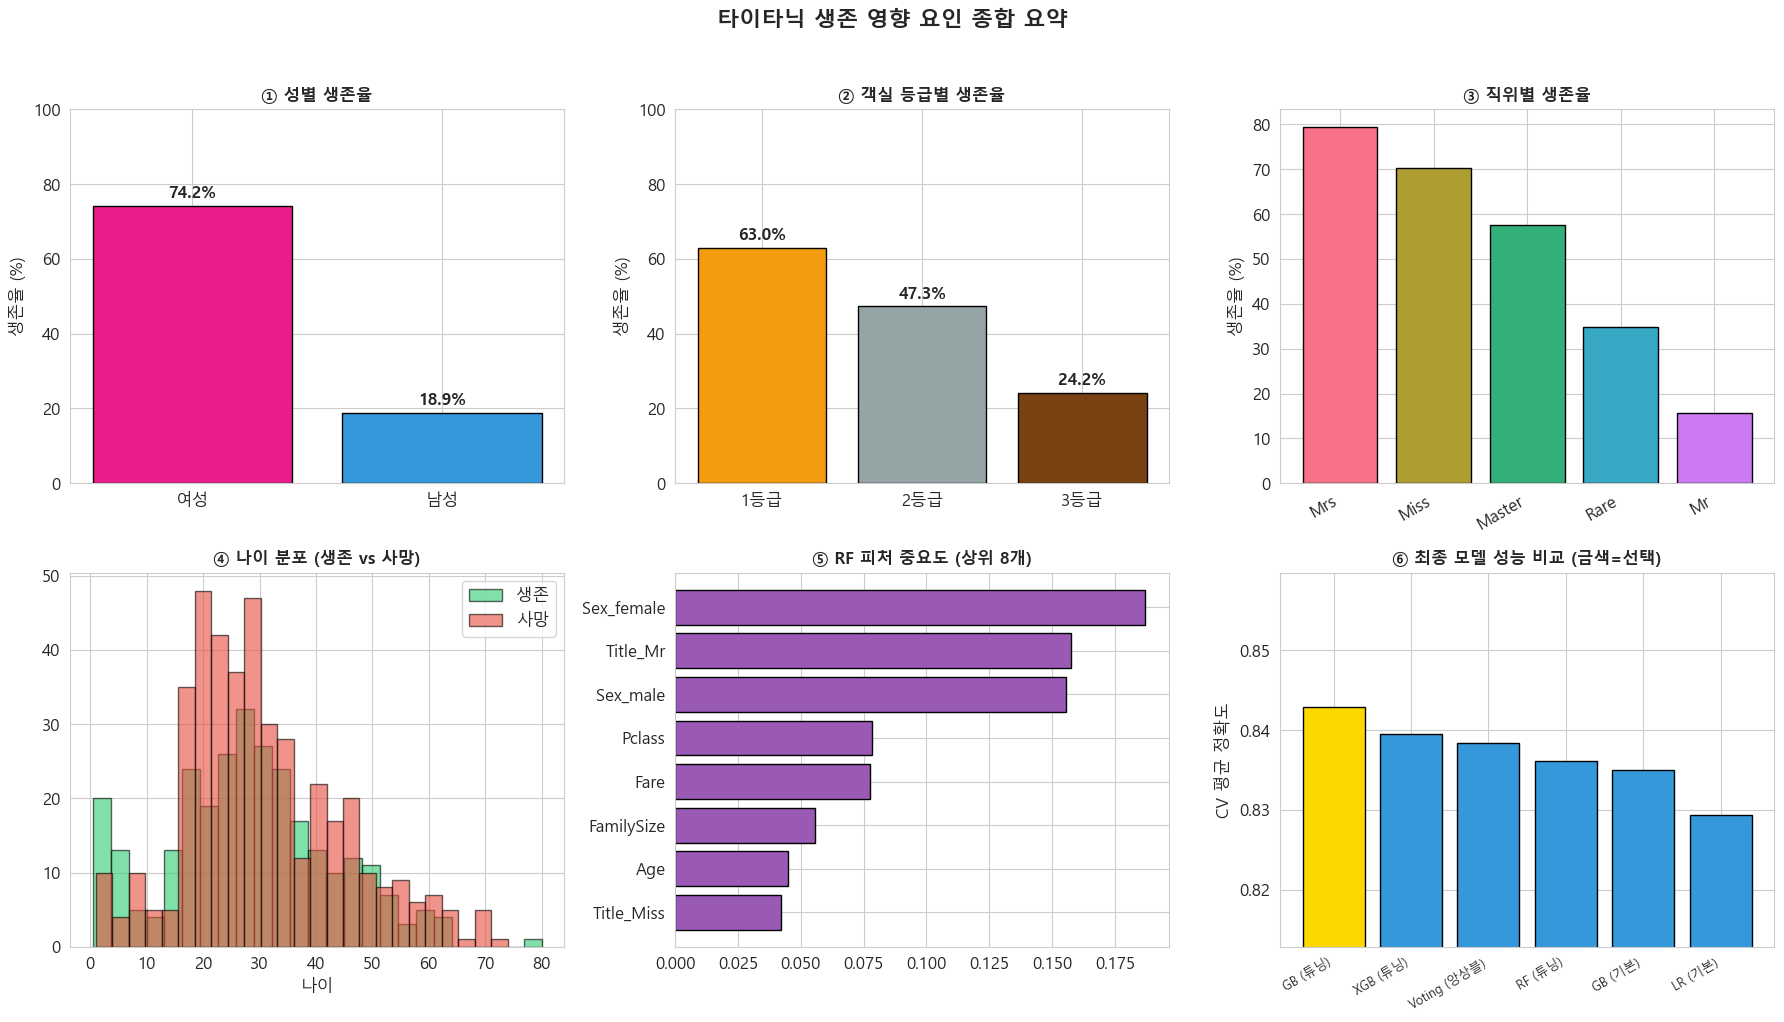

요약 그래프 저장 완료: titanic_summary.png


In [36]:
# ── EDA 주요 발견사항 시각화 요약 ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('타이타닉 생존 영향 요인 종합 요약', fontsize=16, fontweight='bold', y=1.02)

# 1) 성별 생존율
sex_s = train_df.groupby('Sex')['Survived'].mean() * 100
axes[0][0].bar(['여성', '남성'], [sex_s['female'], sex_s['male']],
               color=['#e91e8c', '#3498db'], edgecolor='black')
axes[0][0].set_title('① 성별 생존율', fontsize=12, fontweight='bold')
axes[0][0].set_ylabel('생존율 (%)')
axes[0][0].set_ylim(0, 100)
for i, v in enumerate([sex_s['female'], sex_s['male']]):
    axes[0][0].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# 2) 객실 등급 생존율
pclass_s = train_df.groupby('Pclass')['Survived'].mean() * 100
axes[0][1].bar(['1등급', '2등급', '3등급'], pclass_s,
               color=['#f39c12','#95a5a6','#784212'], edgecolor='black')
axes[0][1].set_title('② 객실 등급별 생존율', fontsize=12, fontweight='bold')
axes[0][1].set_ylabel('생존율 (%)')
axes[0][1].set_ylim(0, 100)
for i, v in enumerate(pclass_s):
    axes[0][1].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# 3) 직위 생존율
title_s = train_fe.groupby('Title')['Survived'].mean().sort_values(ascending=False) * 100
axes[0][2].bar(title_s.index, title_s, color=sns.color_palette('husl', len(title_s)), edgecolor='black')
axes[0][2].set_title('③ 직위별 생존율', fontsize=12, fontweight='bold')
axes[0][2].set_ylabel('생존율 (%)')
axes[0][2].set_xticklabels(title_s.index, rotation=30, ha='right')

# 4) 나이 분포
train_df[train_df['Survived']==1]['Age'].dropna().hist(
    ax=axes[1][0], bins=25, alpha=0.6, color='#2ecc71', label='생존', edgecolor='black')
train_df[train_df['Survived']==0]['Age'].dropna().hist(
    ax=axes[1][0], bins=25, alpha=0.6, color='#e74c3c', label='사망', edgecolor='black')
axes[1][0].set_title('④ 나이 분포 (생존 vs 사망)', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('나이')
axes[1][0].legend()

# 5) 피처 중요도 (상위 8개)
top8 = feature_importances.head(8)
axes[1][1].barh(top8['feature'], top8['importance'], color='#9b59b6', edgecolor='black')
axes[1][1].set_title('⑤ RF 피처 중요도 (상위 8개)', fontsize=12, fontweight='bold')
axes[1][1].invert_yaxis()   # 가장 중요한 피처가 위에 오게

# 6) 모델 성능 비교
sorted_final = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)
names_f  = [x[0] for x in sorted_final]
scores_f = [x[1] for x in sorted_final]
colors_f = ['gold' if n == best_model_name else '#3498db' for n in names_f]
axes[1][2].bar(range(len(names_f)), scores_f, color=colors_f, edgecolor='black')
axes[1][2].set_xticks(range(len(names_f)))
axes[1][2].set_xticklabels(names_f, rotation=30, ha='right', fontsize=9)
axes[1][2].set_title('⑥ 최종 모델 성능 비교 (금색=선택)', fontsize=12, fontweight='bold')
axes[1][2].set_ylabel('CV 평균 정확도')
axes[1][2].set_ylim(min(scores_f)*0.98, max(scores_f)*1.02)

plt.tight_layout()
plt.savefig('titanic_summary.png', dpi=150, bbox_inches='tight')  # 이미지로 저장
plt.show()
print("요약 그래프 저장 완료: titanic_summary.png")

In [37]:
# ── 결론 출력 ─────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║              타이타닉 생존 예측 분석 — 최종 결론               ║
╚══════════════════════════════════════════════════════════════╝

【 핵심 발견사항 (EDA) 】

  1. 성별이 가장 강력한 생존 예측 변수
     - 여성 생존율 ~74%  vs  남성 생존율 ~19%
     - "여성과 어린이 먼저" 원칙이 데이터에서 명확히 확인됨

  2. 객실 등급 = 사회경제적 지위 = 생존 격차
     - 1등급: ~63%  /  2등급: ~47%  /  3등급: ~24%
     - 상위 등급일수록 구명보트 접근이 용이했음

  3. 나이 패턴
     - 0-10세(어린이) 생존율 가장 높음 → "어린이 먼저" 원칙 확인
     - 60세 이상 고령자 생존율 낮음

  4. 가족 규모
     - 1-3명 소가족이 혼자 탑승보다 생존율 높음
     - 4명 이상 대가족은 이동 어려움으로 생존율 다시 낮아짐

  5. 직위(Title)의 강력한 예측력
     - Mrs/Miss(기혼·미혼 여성): ~70% 이상 생존
     - Mr(남성): ~16% 생존
     - 이름에서 파생한 새 변수가 원본보다 유용함을 확인

【 피처 엔지니어링 효과 】

  새로 만든 변수: Title, FamilySize, IsAlone, HasCabin, AgeBin, FareBin
  → 직위(Title)와 요금 구간(FareBin)이 특히 높은 예측력 보임

【 모델 성능 요약 】
""")

# 성능 표 동적 출력
for name, score in sorted(all_scores.items(), key=lambda x: x[1], reverse=True):
    marker = " ← 최종 선택" if name == best_model_name else ""
    print(f"  {name:<22}: {score:.4f}{marker}")

print(f"""
【 제언 (향후 개선 방향) 】

  1. 스태킹(Stacking) 앙상블
     여러 모델의 예측을 입력으로 하는 메타 모델 추가
     → 보팅보다 더 정교한 앙상블 가능

  2. 추가 피처 엔지니어링
     - 티켓 번호의 접두사(선실 구역 정보 포함 가능)
     - 객실 번호의 알파벳(갑판 위치 → 탈출 거리)

  3. 결측값 고도화
     - KNN Imputation 또는 반복 대입법(Iterative Imputer) 적용
     - 나이 예측을 별도 회귀 모델로 수행

  4. 불균형 처리
     - 사망(61%) > 생존(39%) 불균형 → SMOTE 오버샘플링 고려

  최종 선택 모델: {best_model_name}
  최종 CV 정확도: {best_model_score:.4f} ({best_model_score*100:.2f}%)
""")


╔══════════════════════════════════════════════════════════════╗
║              타이타닉 생존 예측 분석 — 최종 결론               ║
╚══════════════════════════════════════════════════════════════╝

【 핵심 발견사항 (EDA) 】

  1. 성별이 가장 강력한 생존 예측 변수
     - 여성 생존율 ~74%  vs  남성 생존율 ~19%
     - "여성과 어린이 먼저" 원칙이 데이터에서 명확히 확인됨

  2. 객실 등급 = 사회경제적 지위 = 생존 격차
     - 1등급: ~63%  /  2등급: ~47%  /  3등급: ~24%
     - 상위 등급일수록 구명보트 접근이 용이했음

  3. 나이 패턴
     - 0-10세(어린이) 생존율 가장 높음 → "어린이 먼저" 원칙 확인
     - 60세 이상 고령자 생존율 낮음

  4. 가족 규모
     - 1-3명 소가족이 혼자 탑승보다 생존율 높음
     - 4명 이상 대가족은 이동 어려움으로 생존율 다시 낮아짐

  5. 직위(Title)의 강력한 예측력
     - Mrs/Miss(기혼·미혼 여성): ~70% 이상 생존
     - Mr(남성): ~16% 생존
     - 이름에서 파생한 새 변수가 원본보다 유용함을 확인

【 피처 엔지니어링 효과 】

  새로 만든 변수: Title, FamilySize, IsAlone, HasCabin, AgeBin, FareBin
  → 직위(Title)와 요금 구간(FareBin)이 특히 높은 예측력 보임

【 모델 성능 요약 】

  GB (튜닝)               : 0.8429 ← 최종 선택
  XGB (튜닝)              : 0.8395
  Voting (앙상블)          : 0.8384
  RF (튜닝)               : 0.8361
  GB (기본)              

In [38]:
# ── Kaggle 제출 파일 생성 ─────────────────────────────────────
# Kaggle은 PassengerId, Survived 두 컬럼만 있는 CSV 파일을 요구

# 테스트 데이터에 대한 최종 예측 실행
test_predictions = final_model.predict(X_test)

# 제출 파일 DataFrame 생성
submission = pd.DataFrame({
    'PassengerId': test_ids,            # 앞에서 저장해둔 테스트 승객 ID
    'Survived':   test_predictions      # 모델이 예측한 생존 여부 (0 or 1)
})

# CSV 파일로 저장 (index=False: 행 번호 제외)
submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"   제출 파일 생성 완료: {submission_path}")
print(f"   총 {len(submission)}명에 대한 예측 완료")
print(f"   생존 예측(1): {submission['Survived'].sum()}명 ({submission['Survived'].mean()*100:.1f}%)")
print(f"   사망 예측(0): {(submission['Survived']==0).sum()}명 ({(submission['Survived']==0).mean()*100:.1f}%)")
print()
print("제출 파일 미리보기:")
print(submission.head(10))

   제출 파일 생성 완료: submission.csv
   총 418명에 대한 예측 완료
   생존 예측(1): 152명 (36.4%)
   사망 예측(0): 266명 (63.6%)

제출 파일 미리보기:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0


In [39]:
# ── 분석 파이프라인 최종 요약 ─────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║                   분석 파이프라인 요약                         ║
╚══════════════════════════════════════════════════════════════╝

 [섹션 1] 데이터 탐색 및 전처리
   ├─ 학습 891건 / 테스트 418건 로드
   ├─ 결측값 처리: Age(그룹 중앙값), Embarked(최빈값), Fare(중앙값)
   ├─ 피처 엔지니어링: Title, FamilySize, IsAlone, HasCabin, AgeBin, FareBin
   ├─ 범주형 인코딩: One-Hot Encoding (Sex, Embarked, Title)
   └─ 수치형 표준화: StandardScaler (Age, Fare, FamilySize 등)

 [섹션 2] 모델 생성 및 교차 검증
   ├─ 7개 모델 5-겹 교차 검증 비교
   │   (LR, DT, RF, GB, SVM, KNN, XGBoost)
   └─ ROC 커브 및 AUC로 세부 성능 평가

 [섹션 3] 하이퍼파라미터 최적화 및 최종 모델
   ├─ RF: GridSearchCV (216개 조합 탐색)
   ├─ XGB: RandomizedSearchCV (50개 조합 탐색)
   ├─ GB: GridSearchCV (36개 조합 탐색)
   ├─ Soft Voting 앙상블 구성
   └─ 최종 선택 모델로 전체 학습 데이터 훈련

 [섹션 4] 결론 및 제언
   ├─ 주요 생존 요인: 성별 > 객실 등급 > 직위 > 요금
   ├─ 피처 중요도 분석으로 모델 해석성 확보
   └─ submission.csv 생성 → Kaggle 제출 준비 완료
""")


╔══════════════════════════════════════════════════════════════╗
║                   분석 파이프라인 요약                         ║
╚══════════════════════════════════════════════════════════════╝

 [섹션 1] 데이터 탐색 및 전처리
   ├─ 학습 891건 / 테스트 418건 로드
   ├─ 결측값 처리: Age(그룹 중앙값), Embarked(최빈값), Fare(중앙값)
   ├─ 피처 엔지니어링: Title, FamilySize, IsAlone, HasCabin, AgeBin, FareBin
   ├─ 범주형 인코딩: One-Hot Encoding (Sex, Embarked, Title)
   └─ 수치형 표준화: StandardScaler (Age, Fare, FamilySize 등)

 [섹션 2] 모델 생성 및 교차 검증
   ├─ 7개 모델 5-겹 교차 검증 비교
   │   (LR, DT, RF, GB, SVM, KNN, XGBoost)
   └─ ROC 커브 및 AUC로 세부 성능 평가

 [섹션 3] 하이퍼파라미터 최적화 및 최종 모델
   ├─ RF: GridSearchCV (216개 조합 탐색)
   ├─ XGB: RandomizedSearchCV (50개 조합 탐색)
   ├─ GB: GridSearchCV (36개 조합 탐색)
   ├─ Soft Voting 앙상블 구성
   └─ 최종 선택 모델로 전체 학습 데이터 훈련

 [섹션 4] 결론 및 제언
   ├─ 주요 생존 요인: 성별 > 객실 등급 > 직위 > 요금
   ├─ 피처 중요도 분석으로 모델 해석성 확보
   └─ submission.csv 생성 → Kaggle 제출 준비 완료

